# 🤖 APRENDIZAJE AUTOMÁTICO

## Trabajo Final Integrador

# "Aprendizaje No Supervisado Aplicado al Consumo de Sustancias Psicoactivas en Jóvenes: Un Enfoque Nacional con Perspectiva Territorial en Tierra del Fuego"


---

### 🎓 Estudiante
**Barbara Jesabel Rigoni**


### 🏫 Institución
**Centro Politécnico Superior Malvinas Argentinas**

### 📚 Carrera
**Tecnicatura Superior en Ciencia de Datos e Inteligencia Artificial**

### 📖 Materia
**Aprendizaje Automático**

### 💻 Profesor
**Nicolás Caballero**

### 📅 Año
**2026**

### 📆 Fecha de Entrega
**17 de Junio de 2026**

---

## 🎯 Objetivo del Proyecto

Identificar perfiles de jóvenes argentinos de 16 a 24 años mediante técnicas de Aprendizaje No Supervisado (Clustering), utilizando variables sociodemográficas, familiares, territoriales y de salud, con el fin de analizar factores asociados al consumo de sustancias psicoactivas.

---

## 📊 Dataset

**Encuesta Nacional sobre Prevalencias de Consumo de Sustancias Psicoactivas (ENPreCoSP 2011)**

Fuente: **INDEC / Ministerio de Salud / SEDRONAR**

---

## 🛠 Herramientas Utilizadas

- Python
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib
- Seaborn
- Google Colab
- GitHub

---

## 🔍 Técnicas Aplicadas

- Análisis Exploratorio de Datos (EDA)
- Preprocesamiento de Datos
- Tratamiento de Valores Faltantes
- Escalado de Variables
- Clustering con K-Means
- Método del Codo (Elbow Method)
- PCA para Visualización
- Evaluación mediante Silhouette Score
- Evaluación mediante Davies-Bouldin Index

---

# Desarrollo del Proyecto

In [ ]:
# Exploración del Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
ORDER   = ['Low', 'Medium', 'High']

# ---- CARGA DEL DATASET ----
df = pd.read_csv('/content/drive/MyDrive/Aprendizaje Automático/Parcial/Archivos Parcial/Base Usuario ENPreCoSP-2011.txt',
                 sep='|',
                 encoding='latin-1',
                 index_col=False)

# ---- DIMENSIONES GENERALES ----
print("=== DIMENSIONES DEL DATASET COMPLETO ===")
print(f"Filas (registros): {df.shape[0]}")
print(f"Columnas (variables): {df.shape[1]}")

# ---- TIPOS DE DATOS ----
print("\n=== TIPOS DE DATOS ===")
print(df.dtypes.value_counts())

# ---- FILTRO JÓVENES 16-24 AÑOS ----
jovenes = df[df['GRUPEDAD'] == 2]
print(f"\n=== SUBCONJUNTO JÓVENES 16-24 AÑOS ===")
print(f"Registros nacionales: {len(jovenes)}")

# ---- FILTRO TIERRA DEL FUEGO ----
tdf = jovenes[jovenes['PRVNC'] == 94]
print(f"Registros Tierra del Fuego: {len(tdf)}")

# ---- VARIABLES DEL PROYECTO ----
vars_proyecto = ['BHCH04','BHCH05','NIVINSTR','CONDACT','TIPO_H',
                 'NBI_TOTAL','RANGOING','BISG01','BISG04','BIAC01',
                 'BIAC02','BIAC03','BIAC04','REGION','POB_URB','PRVNC']

print("\n=== VARIABLES PREDICTORAS ===")
print(jovenes[vars_proyecto].describe())

# ---- VALORES NULOS ----
print("\n=== VALORES NULOS POR VARIABLE ===")
print(jovenes[vars_proyecto].isnull().sum())

# ---- VARIABLES DE CONSUMO ----
vars_consumo = ['P1A_BA','P1A_TA','P1A_MA','P1A_CO','P1A_PB','P1A_TR']
print("\n=== VARIABLES DE CONSUMO (último año) ===")
for v in vars_consumo:
    si = (jovenes[v] == 1).sum()
    total = jovenes[v].notna().sum()
    pct = si/total*100
    print(f"{v}: {si} consumidores ({pct:.1f}%)")

=== DIMENSIONES DEL DATASET COMPLETO ===
Filas (registros): 34343
Columnas (variables): 291

=== TIPOS DE DATOS ===
float64    166
int64      125
Name: count, dtype: int64

=== SUBCONJUNTO JÓVENES 16-24 AÑOS ===
Registros nacionales: 6592
Registros Tierra del Fuego: 265

=== VARIABLES PREDICTORAS ===
            BHCH04       BHCH05     NIVINSTR      CONDACT       TIPO_H  \
count  6592.000000  6592.000000  6592.000000  6592.000000  6592.000000   
mean      1.519266    20.125000     4.552336     2.029430     4.811742   
std       0.499667     2.543179     1.182481     0.965046     1.770790   
min       1.000000    16.000000     1.000000     1.000000     1.000000   
25%       1.000000    18.000000     4.000000     1.000000     4.000000   
50%       2.000000    20.000000     4.000000     2.000000     4.000000   
75%       2.000000    22.000000     6.000000     3.000000     6.000000   
max       2.000000    24.000000     8.000000     3.000000     8.000000   

         NBI_TOTAL     RANGOING

In [ ]:
# PERFIL DEL SUBCONJUNTO JÓVENES 16-24 AÑOS

print("\n" + "="*60)
print("PERFIL DEL SUBCONJUNTO DE TRABAJO (16-24 AÑOS)")
print("="*60)

total = len(jovenes)

# ---- SEXO ----
varones = (jovenes['BHCH04'] == 1).sum()
mujeres = (jovenes['BHCH04'] == 2).sum()

pct_varones = varones / total * 100
pct_mujeres = mujeres / total * 100

print("\nSexo")
print(f"Varón: {varones:,} ({pct_varones:.1f}%)")
print(f"Mujer: {mujeres:,} ({pct_mujeres:.1f}%)")

# ---- EDAD ----
edad_prom = jovenes['BHCH05'].mean()
edad_min = jovenes['BHCH05'].min()
edad_max = jovenes['BHCH05'].max()

print("\nEdad")
print(f"Promedio: {edad_prom:.1f} años")
print(f"Mínima: {edad_min}")
print(f"Máxima: {edad_max}")

# ---- CONSUMO ÚLTIMO AÑO ----
consumos = {
    'Alcohol (último año)': 'P1A_BA',
    'Tabaco (último año)': 'P1A_TA',
    'Marihuana (último año)': 'P1A_MA',
    'Cocaína (último año)': 'P1A_CO',
    'Pasta base (último año)': 'P1A_PB',
    'Tranquilizantes (último año)': 'P1A_TR'
}

print("\nConsumo de sustancias (último año)")
print("-"*60)

for nombre, variable in consumos.items():
    consumidores = (jovenes[variable] == 1).sum()
    porcentaje = consumidores / total * 100

    print(f"{nombre}: {consumidores:,} consumidores ({porcentaje:.1f}%)")


PERFIL DEL SUBCONJUNTO DE TRABAJO (16-24 AÑOS)

Sexo
Varón: 3,169 (48.1%)
Mujer: 3,423 (51.9%)

Edad
Promedio: 20.1 años
Mínima: 16
Máxima: 24

Consumo de sustancias (último año)
------------------------------------------------------------
Alcohol (último año): 4,444 consumidores (67.4%)
Tabaco (último año): 2,139 consumidores (32.4%)
Marihuana (último año): 283 consumidores (4.3%)
Cocaína (último año): 61 consumidores (0.9%)
Pasta base (último año): 4 consumidores (0.1%)
Tranquilizantes (último año): 74 consumidores (1.1%)


In [ ]:
# VARIABLES SELECCIONADAS PARA EL PROYECTO

descripcion = {
    'BHCH04': 'Sexo',
    'BHCH05': 'Edad en años cumplidos',
    'NIVINSTR': 'Nivel de instrucción',
    'CONDACT': 'Condición de actividad',
    'TIPO_H': 'Tipo de hogar',
    'NBI_TOTAL': 'Necesidades Básicas Insatisfechas',
    'RANGOING': 'Rango de ingreso del hogar',
    'BISG01': 'Autopercepción de salud general',
    'BISG04': 'Visita profesional de salud mental',
    'BIAC01': 'Conoce consumidores cercanos',
    'BIAC02': 'Cantidad de consumidores cercanos',
    'BIAC03': 'Curiosidad por probar drogas',
    'BIAC04': 'Posibilidad de acceso a drogas',
    'REGION': 'Región estadística del país',
    'POB_URB': 'Tamaño de aglomerado urbano',
    'PRVNC': 'Provincia de residencia'
}

categoria = {
    'BHCH04': 'Sociodemográfica',
    'BHCH05': 'Sociodemográfica',
    'NIVINSTR': 'Sociodemográfica',
    'CONDACT': 'Sociodemográfica',

    'TIPO_H': 'Contexto familiar',
    'NBI_TOTAL': 'Contexto familiar',
    'RANGOING': 'Contexto familiar',

    'BISG01': 'Salud y entorno',
    'BISG04': 'Salud y entorno',
    'BIAC01': 'Salud y entorno',
    'BIAC02': 'Salud y entorno',
    'BIAC03': 'Salud y entorno',
    'BIAC04': 'Salud y entorno',

    'REGION': 'Territorial',
    'POB_URB': 'Territorial',
    'PRVNC': 'Territorial'
}

# Construcción de la tabla resumen
tabla_variables = pd.DataFrame({
    'Variable': vars_proyecto,
    'Descripción': [descripcion[v] for v in vars_proyecto],
    'Categoría': [categoria[v] for v in vars_proyecto],
    'Valores únicos': [jovenes[v].nunique(dropna=True) for v in vars_proyecto],
    'Nulos/Ns': [jovenes[v].isnull().sum() for v in vars_proyecto]
})

print("\n=== VARIABLES SELECCIONADAS PARA EL PROYECTO ===")
print(tabla_variables)

# Opcional: mostrar completa sin cortes
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


=== VARIABLES SELECCIONADAS PARA EL PROYECTO ===
     Variable                         Descripción          Categoría  \
0      BHCH04                                Sexo   Sociodemográfica   
1      BHCH05              Edad en años cumplidos   Sociodemográfica   
2    NIVINSTR                Nivel de instrucción   Sociodemográfica   
3     CONDACT              Condición de actividad   Sociodemográfica   
4      TIPO_H                       Tipo de hogar  Contexto familiar   
5   NBI_TOTAL   Necesidades Básicas Insatisfechas  Contexto familiar   
6    RANGOING          Rango de ingreso del hogar  Contexto familiar   
7      BISG01     Autopercepción de salud general    Salud y entorno   
8      BISG04  Visita profesional de salud mental    Salud y entorno   
9      BIAC01        Conoce consumidores cercanos    Salud y entorno   
10     BIAC02   Cantidad de consumidores cercanos    Salud y entorno   
11     BIAC03        Curiosidad por probar drogas    Salud y entorno   
12     BIAC04 

In [ ]:
# VARIABLES DE CONSUMO (ÚLTIMO AÑO)

variables_consumo = {
    'P1A_BA': 'Bebidas alcohólicas',
    'P1A_TA': 'Tabaco',
    'P1A_MA': 'Marihuana',
    'P1A_CO': 'Cocaína',
    'P1A_PB': 'Pasta base',
    'P1A_TR': 'Tranquilizantes sin receta'
}

tabla_consumo = []

for var, sustancia in variables_consumo.items():

    consumidores = (jovenes[var] == 1).sum()

    # porcentaje sobre el total de jóvenes
    porcentaje = consumidores / len(jovenes) * 100

    tabla_consumo.append([
        var,
        sustancia,
        consumidores,
        round(porcentaje, 1)
    ])

tabla_consumo = pd.DataFrame(
    tabla_consumo,
    columns=[
        'Variable',
        'Sustancia',
        'Consumidores (último año)',
        'Porcentaje (%)'
    ]
)

print("\n=== VARIABLES DE CONSUMO ===")
print(tabla_consumo)


=== VARIABLES DE CONSUMO ===
  Variable                   Sustancia  Consumidores (último año)  \
0   P1A_BA         Bebidas alcohólicas                       4444   
1   P1A_TA                      Tabaco                       2139   
2   P1A_MA                   Marihuana                        283   
3   P1A_CO                     Cocaína                         61   
4   P1A_PB                  Pasta base                          4   
5   P1A_TR  Tranquilizantes sin receta                         74   

   Porcentaje (%)  
0            67.4  
1            32.4  
2             4.3  
3             0.9  
4             0.1  
5             1.1  


In [ ]:
print("\nVARIABLES DE CONSUMO (ANÁLISIS DESCRIPTIVO)")
print("-"*80)

for _, fila in tabla_consumo.iterrows():
    print(
        f"{fila['Variable']:8} | "
        f"{fila['Sustancia']:30} | "
        f"{fila['Consumidores (último año)']:5,d} consumidores | "
        f"{fila['Porcentaje (%)']:.1f}%"
    )


VARIABLES DE CONSUMO (ANÁLISIS DESCRIPTIVO)
--------------------------------------------------------------------------------
P1A_BA   | Bebidas alcohólicas            | 4,444 consumidores | 67.4%
P1A_TA   | Tabaco                         | 2,139 consumidores | 32.4%
P1A_MA   | Marihuana                      |   283 consumidores | 4.3%
P1A_CO   | Cocaína                        |    61 consumidores | 0.9%
P1A_PB   | Pasta base                     |     4 consumidores | 0.1%
P1A_TR   | Tranquilizantes sin receta     |    74 consumidores | 1.1%


In [ ]:
tabla_consumo.style.format({
    'Consumidores (último año)': '{:,.0f}',
    'Porcentaje (%)': '{:.1f}%'
})

,Variable,Sustancia,Consumidores (último año),Porcentaje (%)
0,P1A_BA,Bebidas alcohólicas,"4,444",67.4%
1,P1A_TA,Tabaco,"2,139",32.4%
2,P1A_MA,Marihuana,283,4.3%
3,P1A_CO,Cocaína,61,0.9%
4,P1A_PB,Pasta base,4,0.1%
5,P1A_TR,Tranquilizantes sin receta,74,1.1%


## Preprocesamiento de Datos

El preprocesamiento transforma los datos crudos en un formato adecuado
para los algoritmos de clustering. Se realizaran los siguientes pasos:

1. Selección de las 16 variables del proyecto
2. Tratamiento de valores faltantes y códigos de no respuesta
3. Codificación de variables categóricas
4. Normalización de variables numéricas

In [ ]:
# ============================================
# PASO 1 — SELECCIÓN DE VARIABLES
# ============================================

vars_clustering = ['BHCH04','BHCH05','NIVINSTR','CONDACT','TIPO_H',
                   'NBI_TOTAL','RANGOING','BISG01','BISG04','BIAC01',
                   'BIAC02','BIAC03','BIAC04','REGION','POB_URB','PRVNC']

# Crear subconjunto de trabajo
df_trabajo = jovenes[vars_clustering].copy()

print("=== SUBCONJUNTO DE TRABAJO ===")
print(f"Registros: {df_trabajo.shape[0]}")
print(f"Variables: {df_trabajo.shape[1]}")
print(f"\nValores nulos antes del tratamiento:")
print(df_trabajo.isnull().sum())

=== SUBCONJUNTO DE TRABAJO ===
Registros: 6592
Variables: 16

Valores nulos antes del tratamiento:
BHCH04          0
BHCH05          0
NIVINSTR        0
CONDACT         0
TIPO_H          0
NBI_TOTAL       0
RANGOING        0
BISG01          0
BISG04          0
BIAC01          0
BIAC02       3979
BIAC03          0
BIAC04          0
REGION          0
POB_URB         0
PRVNC           0
dtype: int64


> **Nota:**

> - `BIAC02` tiene 3.979 valores nulos → esto tiene sentido porque es la variable "¿Cuántas personas consumidoras cercanas conoce?" y solo la responden quienes contestaron Sí en BIAC01.

>  **¿Eliminar la variable o imputar?**

> - Elijo eliminar la variable `BIAC02`. Ya que `BIAC01` captura si conoce o no consumidores, BIAC02 es redundante y puede eliminarse.

*Decidi 'eliminar' y no 'imputar la variable, ya que -> 3.979 nulos sobre 6.592 registros es el 60%, demasiado para imputar.*



In [ ]:
# ============================================
# PASO 2 — TRATAMIENTO DE VALORES FALTANTES
# ============================================

# BIAC02 tiene 3.979 nulos (60%) → se elimina
# BIAC01 ya captura si conoce consumidores cercanos
df_trabajo = df_trabajo.drop(columns=['BIAC02'])

print("=== DESPUÉS DE ELIMINAR BIAC02 ===")
print(f"Variables restantes: {df_trabajo.shape[1]}")
print(f"\nValores nulos:")
print(df_trabajo.isnull().sum())

=== DESPUÉS DE ELIMINAR BIAC02 ===
Variables restantes: 15

Valores nulos:
BHCH04       0
BHCH05       0
NIVINSTR     0
CONDACT      0
TIPO_H       0
NBI_TOTAL    0
RANGOING     0
BISG01       0
BISG04       0
BIAC01       0
BIAC03       0
BIAC04       0
REGION       0
POB_URB      0
PRVNC        0
dtype: int64


> Nota:

El dataset está limpio, con 15 variables y 0 valores nulos.
Antes de continuar con la Normalización, necesito revisar si en las variables existen lo que el diccionario indica como 'No sabe / No contesta', representado con los códigos 9, 99 y 999.


In [ ]:
# ============================================
# PASO 3 — TRATAMIENTO DE CÓDIGOS NS/NC
# ============================================

# Según el diccionario, 9/99/999 = No sabe / No contesta
codigos_nsnc = {
    'BHCH04': [9],
    'NIVINSTR': [9],
    'CONDACT': [9],
    'RANGOING': [99],
    'BISG01': [9],
    'BISG04': [9],
    'BIAC01': [9],
    'BIAC03': [9],
    'BIAC04': [9],
}

print("=== CÓDIGOS NS/NC POR VARIABLE ===")
for var, codigos in codigos_nsnc.items():
    if var in df_trabajo.columns:
        for codigo in codigos:
            count = (df_trabajo[var] == codigo).sum()
            if count > 0:
                print(f"{var} con código {codigo}: {count} registros")

print("\nVerificación completa.")

=== CÓDIGOS NS/NC POR VARIABLE ===
RANGOING con código 99: 516 registros
BISG04 con código 9: 12 registros
BIAC01 con código 9: 20 registros
BIAC03 con código 9: 20 registros
BIAC04 con código 9: 19 registros

Verificación completa.


In [ ]:
# ============================================
# PASO 4 — REEMPLAZAR CÓDIGOS NS/NC POR NaN
# ============================================

import numpy as np

# Reemplazar códigos NS/NC por NaN
df_trabajo['RANGOING'] = df_trabajo['RANGOING'].replace(99, np.nan)
df_trabajo['BISG04']   = df_trabajo['BISG04'].replace(9, np.nan)
df_trabajo['BIAC01']   = df_trabajo['BIAC01'].replace(9, np.nan)
df_trabajo['BIAC03']   = df_trabajo['BIAC03'].replace(9, np.nan)
df_trabajo['BIAC04']   = df_trabajo['BIAC04'].replace(9, np.nan)

print("=== NULOS DESPUÉS DE REEMPLAZAR NS/NC ===")
print(df_trabajo.isnull().sum())
print(f"\nTotal registros: {len(df_trabajo)}")

=== NULOS DESPUÉS DE REEMPLAZAR NS/NC ===
BHCH04         0
BHCH05         0
NIVINSTR       0
CONDACT        0
TIPO_H         0
NBI_TOTAL      0
RANGOING     516
BISG01         0
BISG04        12
BIAC01        20
BIAC03        20
BIAC04        19
REGION         0
POB_URB        0
PRVNC          0
dtype: int64

Total registros: 6592


Ahora puedo ver los nulos reales.

Imputar:

- RANGOING (516 nulos) → imputar con la mediana porque es una variable ordinal de ingresos.

- BISG04, BIAC01, BIAC03, BIAC04 (12-20 nulos) → imputar con la moda porque son variables categóricas binarias

In [ ]:
# ============================================
# PASO 5 — IMPUTACIÓN DE VALORES FALTANTES
# ============================================

# RANGOING → mediana (variable ordinal de ingresos)
mediana_rangoing = df_trabajo['RANGOING'].median()
df_trabajo['RANGOING'] = df_trabajo['RANGOING'].fillna(mediana_rangoing)
print(f"RANGOING imputado con mediana: {mediana_rangoing}")

# Variables categóricas → moda
vars_moda = ['BISG04', 'BIAC01', 'BIAC03', 'BIAC04']
for var in vars_moda:
    moda = df_trabajo[var].mode()[0]
    df_trabajo[var] = df_trabajo[var].fillna(moda)
    print(f"{var} imputado con moda: {moda}")

# Verificación final
print("\n=== VERIFICACIÓN FINAL DE NULOS ===")
print(df_trabajo.isnull().sum())
print(f"\n✅ Dataset listo: {df_trabajo.shape[0]} registros, {df_trabajo.shape[1]} variables")

RANGOING imputado con mediana: 6.0
BISG04 imputado con moda: 2.0
BIAC01 imputado con moda: 2.0
BIAC03 imputado con moda: 2.0
BIAC04 imputado con moda: 2.0

=== VERIFICACIÓN FINAL DE NULOS ===
BHCH04       0
BHCH05       0
NIVINSTR     0
CONDACT      0
TIPO_H       0
NBI_TOTAL    0
RANGOING     0
BISG01       0
BISG04       0
BIAC01       0
BIAC03       0
BIAC04       0
REGION       0
POB_URB      0
PRVNC        0
dtype: int64

✅ Dataset listo: 6592 registros, 15 variables


Normalización. Como K-Means usa distancias, las variables deben estar en la misma escala:

In [ ]:
# ============================================
# PASO 6 — NORMALIZACIÓN
# ============================================

from sklearn.preprocessing import StandardScaler

# Guardar PRVNC aparte para el análisis de TDF
prvnc = df_trabajo['PRVNC'].copy()

# Normalizar todas las variables
scaler = StandardScaler()
df_escalado = scaler.fit_transform(df_trabajo)

# Convertir a DataFrame conservando los nombres
df_escalado = pd.DataFrame(
    df_escalado,
    columns=df_trabajo.columns,
    index=df_trabajo.index
)

# Restaurar PRVNC sin escalar (la usamos solo para comparación)
df_escalado['PRVNC'] = prvnc.values

print("=== DATASET NORMALIZADO ===")
print(f"Registros: {df_escalado.shape[0]}")
print(f"Variables: {df_escalado.shape[1]}")
print(f"\nEstadísticas después de normalizar:")
print(df_escalado.drop(columns=['PRVNC']).describe().round(2))

=== DATASET NORMALIZADO ===
Registros: 6592
Variables: 15

Estadísticas después de normalizar:
        BHCH04   BHCH05  NIVINSTR  CONDACT   TIPO_H  NBI_TOTAL  RANGOING  \
count  6592.00  6592.00   6592.00  6592.00  6592.00    6592.00   6592.00   
mean     -0.00     0.00     -0.00     0.00     0.00       0.00     -0.00   
std       1.00     1.00      1.00     1.00     1.00       1.00      1.00   
min      -1.04    -1.62     -3.00    -1.07    -2.15      -0.42     -1.90   
25%      -1.04    -0.84     -0.47    -1.07    -0.46      -0.42     -0.55   
50%       0.96    -0.05     -0.47    -0.03    -0.46      -0.42     -0.27   
75%       0.96     0.74      1.22     1.01     0.67      -0.42      0.54   
max       0.96     1.52      2.92     1.01     1.80       7.30      2.71   

        BISG01   BISG04   BIAC01   BIAC03   BIAC04   REGION  POB_URB  
count  6592.00  6592.00  6592.00  6592.00  6592.00  6592.00  6592.00  
mean      0.00    -0.00     0.00     0.00     0.00     0.00     0.00  
std    

### Análisis de resultados
Media ≈ 0 en todas las variables ✅

Desviación estándar = 1 en todas las variables ✅

Eso significa que todas las variables están en la misma escala y K-Means puede trabajar correctamente.

📋 Resumen del preprocesamiento completo
| Paso | Acción | Resultado
|---|---|---|
| 1 | Selección de variables | 16 -> 15 variables
| 2 | Eliminación BIAC02 | 60% nulos, variable redundante
| 3 | Detección NS/NC | 5 variables afectadas
| 4 | Reemplado NS/NC por NaN | 567 valores tratados
| 5 | Imputación | Mediana para RAINGOING, moda para el resto
| 6 | Normalización | Media = 0, Std = 1 en todas las variables


## Análisis Exploratorio de Datos (EDA)

El objetivo del EDA es comprender la distribución de las variables,
identificar patrones y visualizar diferencias entre el subconjunto
nacional y el de Tierra del Fuego, antes de aplicar los modelos
de clustering.

## Distribución por Edad y Sexo

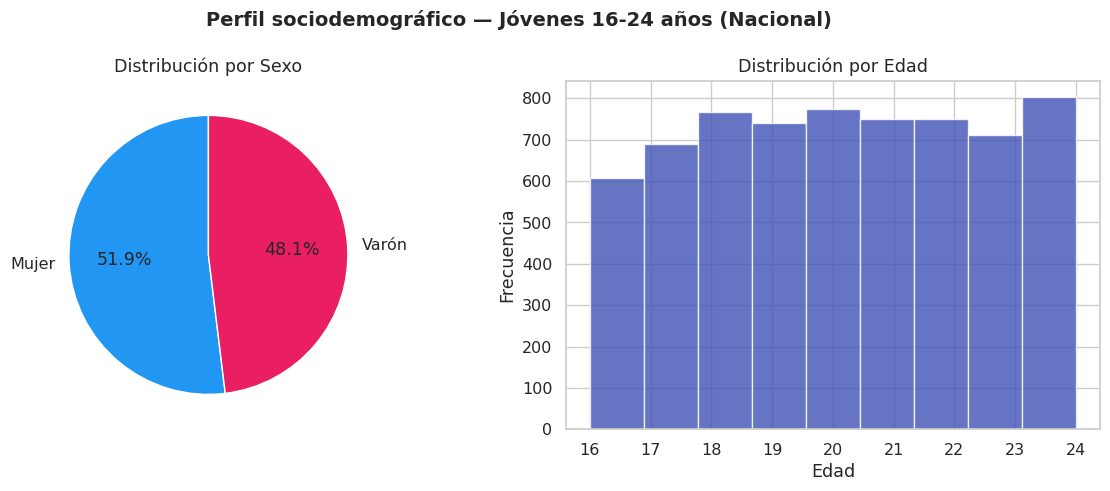

✅ Gráfico 1 guardado


In [ ]:
# ============================================
# EDA — GRÁFICO 1: DISTRIBUCIÓN POR SEXO
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Perfil sociodemográfico — Jóvenes 16-24 años (Nacional)',
             fontsize=14, fontweight='bold')

# Sexo
sexo_counts = jovenes['BHCH04'].map({1: 'Varón', 2: 'Mujer'}).value_counts()
axes[0].pie(sexo_counts,
            labels=sexo_counts.index,
            autopct='%1.1f%%',
            colors=['#2196F3', '#E91E63'],
            startangle=90)
axes[0].set_title('Distribución por Sexo')

# Edad
axes[1].hist(jovenes['BHCH05'], bins=9, color='#3F51B5',
             edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución por Edad')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('grafico1_perfil_sociodemografico.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 1 guardado")

Lo que podemos observar:

- La muestra está bastante equilibrada por sexo (51.9% mujeres / 48.1% varones)

- La distribución por edad es bastante uniforme entre los 16 y 24 años, con un leve pico en los 24

## Consumo de sustancias

"Es importante aclarar la diferencia entre dos términos que se usan en este proyecto. Las sustancias psicoactivas es un término amplio que incluye toda sustancia que afecta el sistema nervioso central: alcohol, tabaco, drogas ilegales (marihuana, cocaína, pasta base) y también psicofármacos. Los psicofármacos son un subgrupo de sustancias psicoactivas: medicamentos de uso psiquiátrico como tranquilizantes y estimulantes, que en este dataset están representados por las variables P1A_TR (tranquilizantes) y P1A_ES (estimulantes), relevados específicamente cuando fueron consumidos sin indicación médica."



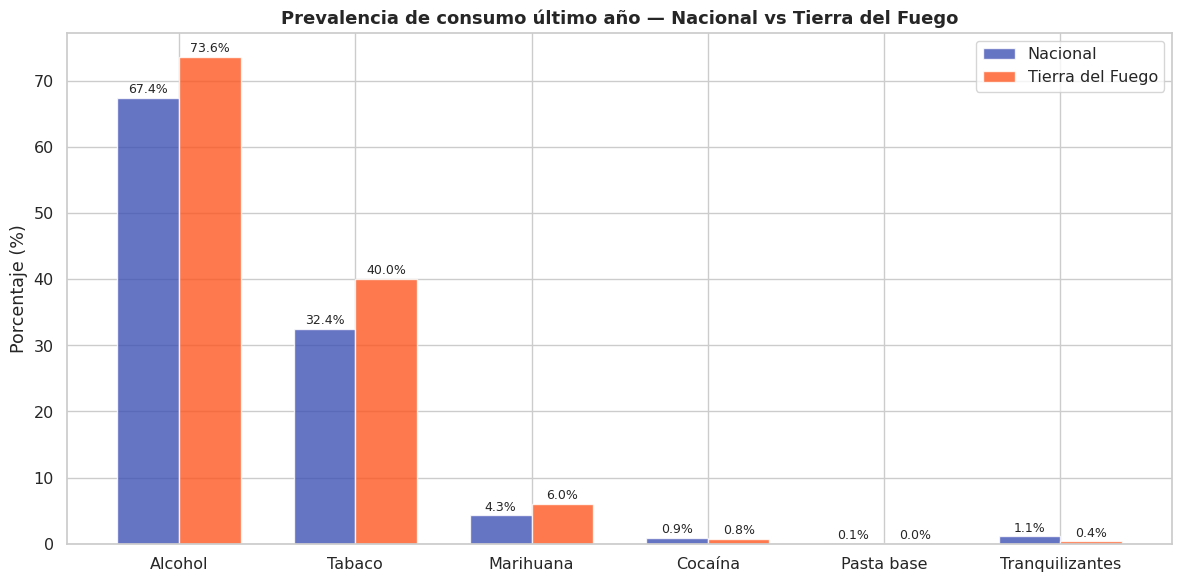

✅ Gráfico 2 guardado


In [ ]:
# ============================================
# EDA — GRÁFICO 2: CONSUMO DE SUSTANCIAS
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

sustancias = ['Alcohol', 'Tabaco', 'Marihuana', 'Cocaína', 'Pasta base', 'Tranquilizantes']
vars_cons = ['P1A_BA', 'P1A_TA', 'P1A_MA', 'P1A_CO', 'P1A_PB', 'P1A_TR']
colores = ['#2196F3', '#FF9800', '#4CAF50', '#F44336', '#9C27B0', '#795548']

# Nacional
pct_nacional = [(jovenes[v] == 1).sum() / len(jovenes) * 100 for v in vars_cons]

# TDF
pct_tdf = [(tdf[v] == 1).sum() / len(tdf) * 100 for v in vars_cons]

x = np.arange(len(sustancias))
width = 0.35

bars1 = ax.bar(x - width/2, pct_nacional, width, label='Nacional', color='#3F51B5', alpha=0.8)
bars2 = ax.bar(x + width/2, pct_tdf, width, label='Tierra del Fuego', color='#FF5722', alpha=0.8)

ax.set_title('Prevalencia de consumo último año — Nacional vs Tierra del Fuego',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sustancias)
ax.set_ylabel('Porcentaje (%)')
ax.legend()

# Agregar valores encima de las barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('grafico2_consumo_sustancias.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 2 guardado")

Este podría ser uno de los gráficos mas relevantes, ya que muestra claramente las diferencias entre TDF y el resto del país.

Se puede observar:

- Alcohol: TDF supera al nacional (73.6% vs 67.4%)
- Tabaco: TDF supera significativamente al nacional (40.0% vs 32.4%)
- Marihuana: TDF levemente superior (6.0% vs 4.3%)
- Cocaína, Pasta base, Tranquilizantes: valores muy bajos en ambos

Esto confirma la teoría inicial: los jóvenes fueguinos tienen prevalencias de consumo superiores a la media nacional, especialmnete en alcohol y tabaco.

##Factores de entorno social

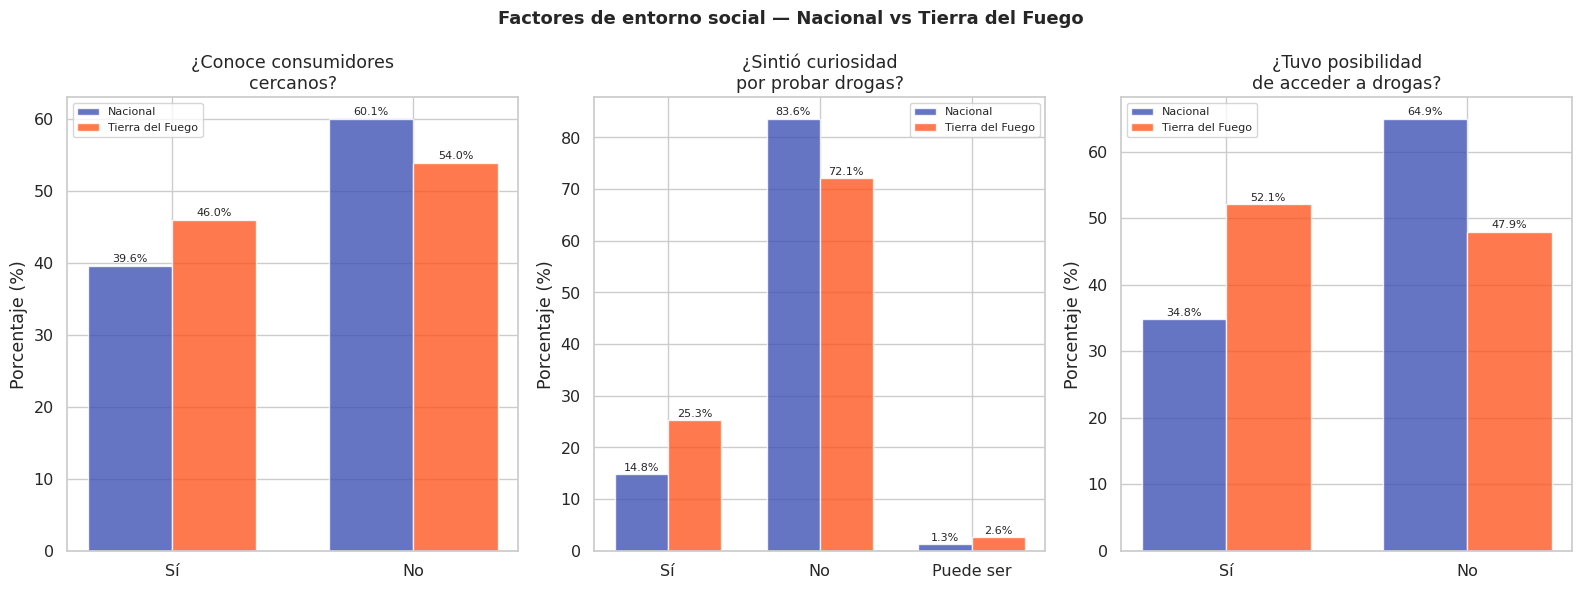

✅ Gráfico 3 guardado


In [ ]:
# ============================================
# EDA — GRÁFICO 3: FACTORES DE ENTORNO SOCIAL
# Nacional vs Tierra del Fuego
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Factores de entorno social — Nacional vs Tierra del Fuego',
             fontsize=13, fontweight='bold')

variables = [
    ('BIAC01', '¿Conoce consumidores\ncercanos?', {1: 'Sí', 2: 'No'}),
    ('BIAC03', '¿Sintió curiosidad\npor probar drogas?', {1: 'Sí', 2: 'No', 3: 'Puede ser'}),
    ('BIAC04', '¿Tuvo posibilidad\nde acceder a drogas?', {1: 'Sí', 2: 'No'}),
]

for ax, (var, titulo, mapeo) in zip(axes, variables):
    categorias = list(mapeo.values())

    # Porcentajes nacional
    pct_nac = [(jovenes[var] == k).sum() / len(jovenes) * 100 for k in mapeo.keys()]

    # Porcentajes TDF
    pct_tdf = [(tdf[var] == k).sum() / len(tdf) * 100 for k in mapeo.keys()]

    x = np.arange(len(categorias))
    width = 0.35

    bars1 = ax.bar(x - width/2, pct_nac, width, label='Nacional',
                   color='#3F51B5', alpha=0.8)
    bars2 = ax.bar(x + width/2, pct_tdf, width, label='Tierra del Fuego',
                   color='#FF5722', alpha=0.8)

    ax.set_title(titulo)
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(categorias)
    ax.legend(fontsize=8)

    # Valores encima de las barras
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('grafico3_entorno_social.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 3 guardado")

Se puede observar:

- Conoce consumidores cercanos: TDF supera al nacional (46% vs 39.6%)
- Curiosidad por probar drogas: TDF casi duplica al nacional (25.3% vs 14.8%)
- Posibilidad de acceso: TDF supera significativamente al nacional (52.1% vs 34.8%)

Tres datos a tener en cuenta a la hora de realizar conclusiones finales.
Sugieren que los jóvenes fueguinos tienen mayor exposición y predisposición al consumo que el promedio nacional.


## Nivel de instrucción y condición de actividad

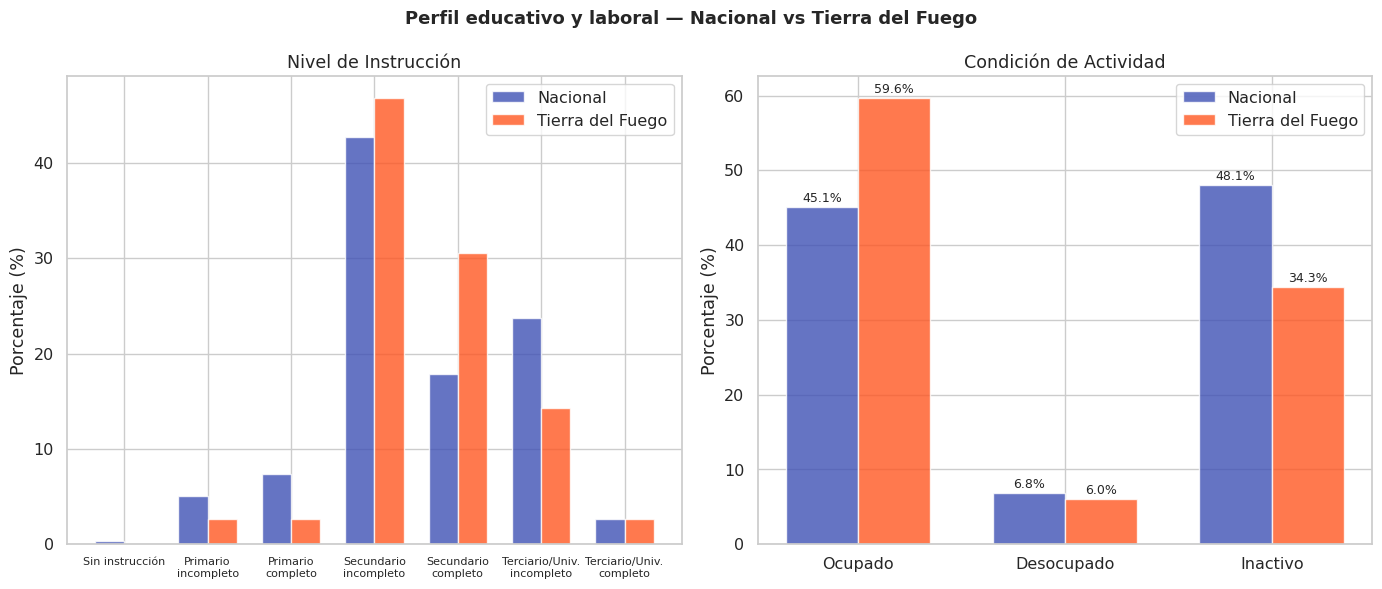

✅ Gráfico 4 guardado


In [ ]:
# ============================================
# EDA — GRÁFICO 4: NIVEL DE INSTRUCCIÓN
# Y CONDICIÓN DE ACTIVIDAD
# Nacional vs Tierra del Fuego
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Perfil educativo y laboral — Nacional vs Tierra del Fuego',
             fontsize=13, fontweight='bold')

# NIVINSTR - Nivel de instrucción
niveles = {1: 'Sin instrucción', 2: 'Primario\nincompleto',
           3: 'Primario\ncompleto', 4: 'Secundario\nincompleto',
           5: 'Secundario\ncompleto', 6: 'Terciario/Univ.\nincompleto',
           7: 'Terciario/Univ.\ncompleto'}

pct_nac = [(jovenes['NIVINSTR'] == k).sum() / len(jovenes) * 100 for k in niveles.keys()]
pct_tdf = [(tdf['NIVINSTR'] == k).sum() / len(tdf) * 100 for k in niveles.keys()]

x = np.arange(len(niveles))
width = 0.35

axes[0].bar(x - width/2, pct_nac, width, label='Nacional', color='#3F51B5', alpha=0.8)
axes[0].bar(x + width/2, pct_tdf, width, label='Tierra del Fuego', color='#FF5722', alpha=0.8)
axes[0].set_title('Nivel de Instrucción')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(niveles.values(), fontsize=8)
axes[0].legend()

# CONDACT - Condición de actividad
actividad = {1: 'Ocupado', 2: 'Desocupado', 3: 'Inactivo'}

pct_nac_act = [(jovenes['CONDACT'] == k).sum() / len(jovenes) * 100 for k in actividad.keys()]
pct_tdf_act = [(tdf['CONDACT'] == k).sum() / len(tdf) * 100 for k in actividad.keys()]

x2 = np.arange(len(actividad))
bars1 = axes[1].bar(x2 - width/2, pct_nac_act, width, label='Nacional', color='#3F51B5', alpha=0.8)
bars2 = axes[1].bar(x2 + width/2, pct_tdf_act, width, label='Tierra del Fuego', color='#FF5722', alpha=0.8)
axes[1].set_title('Condición de Actividad')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(actividad.values())
axes[1].legend()

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('grafico4_educacion_actividad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 4 guardado")

Se puede observar:

**Nivel de instrucción:**

- TDF tiene mayor proporción en Secundario incompleto (~47% vs 43%)
- TDF tiene menor proporción en Terciario/Universitario incompleto (15% vs 24%)
- Sugiere que los jóvenes fueguinos abandonan antes sus estudios

**Condición de actividad:**

- TDF tiene muchos más Ocupados (59.6% vs 45.1%) → inserción laboral temprana
- TDF tiene muchos menos Inactivos (34.3% vs 48.1%)
- Esto es característico de TDF: los jóvenes trabajan antes por el alto costo de vida

## Contexto socioeconómico (NBI e ingresos)

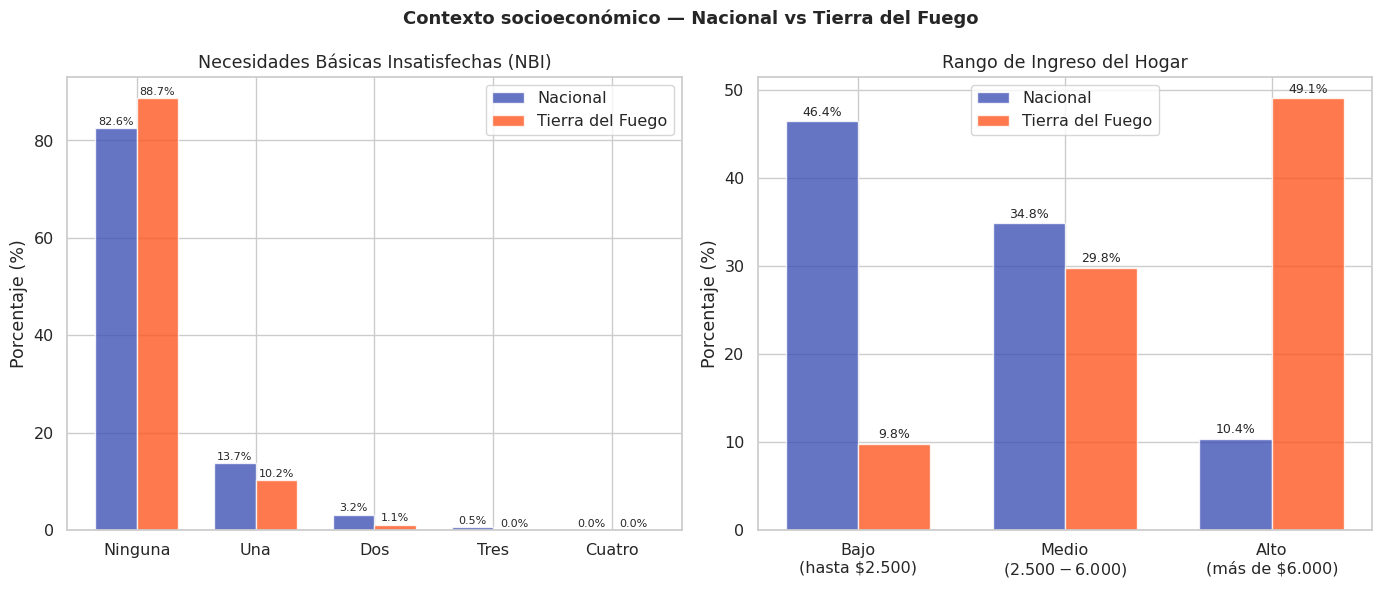

✅ Gráfico 5 guardado


In [ ]:
# ============================================
# EDA — GRÁFICO 5: CONTEXTO SOCIOECONÓMICO
# NBI e Ingresos — Nacional vs Tierra del Fuego
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Contexto socioeconómico — Nacional vs Tierra del Fuego',
             fontsize=13, fontweight='bold')

# NBI_TOTAL - Necesidades Básicas Insatisfechas
nbi_labels = {0: 'Ninguna', 1: 'Una', 2: 'Dos', 3: 'Tres', 4: 'Cuatro'}

pct_nac_nbi = [(jovenes['NBI_TOTAL'] == k).sum() / len(jovenes) * 100 for k in nbi_labels.keys()]
pct_tdf_nbi = [(tdf['NBI_TOTAL'] == k).sum() / len(tdf) * 100 for k in nbi_labels.keys()]

x = np.arange(len(nbi_labels))
width = 0.35

bars1 = axes[0].bar(x - width/2, pct_nac_nbi, width, label='Nacional', color='#3F51B5', alpha=0.8)
bars2 = axes[0].bar(x + width/2, pct_tdf_nbi, width, label='Tierra del Fuego', color='#FF5722', alpha=0.8)
axes[0].set_title('Necesidades Básicas Insatisfechas (NBI)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nbi_labels.values())
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# RANGOING - Rango de ingreso del hogar
# Agrupamos en 3 rangos para simplificar
jovenes_copia = jovenes.copy()
tdf_copia = tdf.copy()

jovenes_copia['RANGO_GRUPO'] = pd.cut(jovenes['RANGOING'],
                                       bins=[0, 6, 12, 17],
                                       labels=['Bajo\n(hasta $2.500)',
                                               'Medio\n($2.500-$6.000)',
                                               'Alto\n(más de $6.000)'])

tdf_copia['RANGO_GRUPO'] = pd.cut(tdf['RANGOING'],
                                   bins=[0, 6, 12, 17],
                                   labels=['Bajo\n(hasta $2.500)',
                                           'Medio\n($2.500-$6.000)',
                                           'Alto\n(más de $6.000)'])

rangos = ['Bajo\n(hasta $2.500)', 'Medio\n($2.500-$6.000)', 'Alto\n(más de $6.000)']
pct_nac_ing = [(jovenes_copia['RANGO_GRUPO'] == r).sum() / len(jovenes_copia) * 100 for r in rangos]
pct_tdf_ing = [(tdf_copia['RANGO_GRUPO'] == r).sum() / len(tdf_copia) * 100 for r in rangos]

x2 = np.arange(len(rangos))
bars3 = axes[1].bar(x2 - width/2, pct_nac_ing, width, label='Nacional', color='#3F51B5', alpha=0.8)
bars4 = axes[1].bar(x2 + width/2, pct_tdf_ing, width, label='Tierra del Fuego', color='#FF5722', alpha=0.8)
axes[1].set_title('Rango de Ingreso del Hogar')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(rangos)
axes[1].legend()

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('grafico5_contexto_socioeconomico.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 5 guardado")

Este gráfico muestra datos muy reveladores sobre TDF.

Se puede observar:

*NBI:*

- TDF tiene menos NBI que el nacional (88.7% en ninguna vs 82.6%)

Sugiere que TDF tiene mejores condiciones habitacionales básicas

*Rango de ingreso:*

- TDF tiene ingresos significativamente más altos (49.1% en rango alto vs solo 10.4% nacional)
- TDF tiene mucho menos ingreso bajo (9.8% vs 46.4% nacional)

Esto refleja el alto costo de vida y los salarios más elevados de la provincia

> *Dato  interesante para conclusiones*

TDF tiene mejores condiciones económicas pero mayor consumo de sustancias. Esto sugiere que el consumo en TDF no está asociado a la pobreza sino a otros factores, que podrían ser el aislamiento geográfico, la disponibilidad de dinero y la escasa oferta recreativa.

## Salud mental

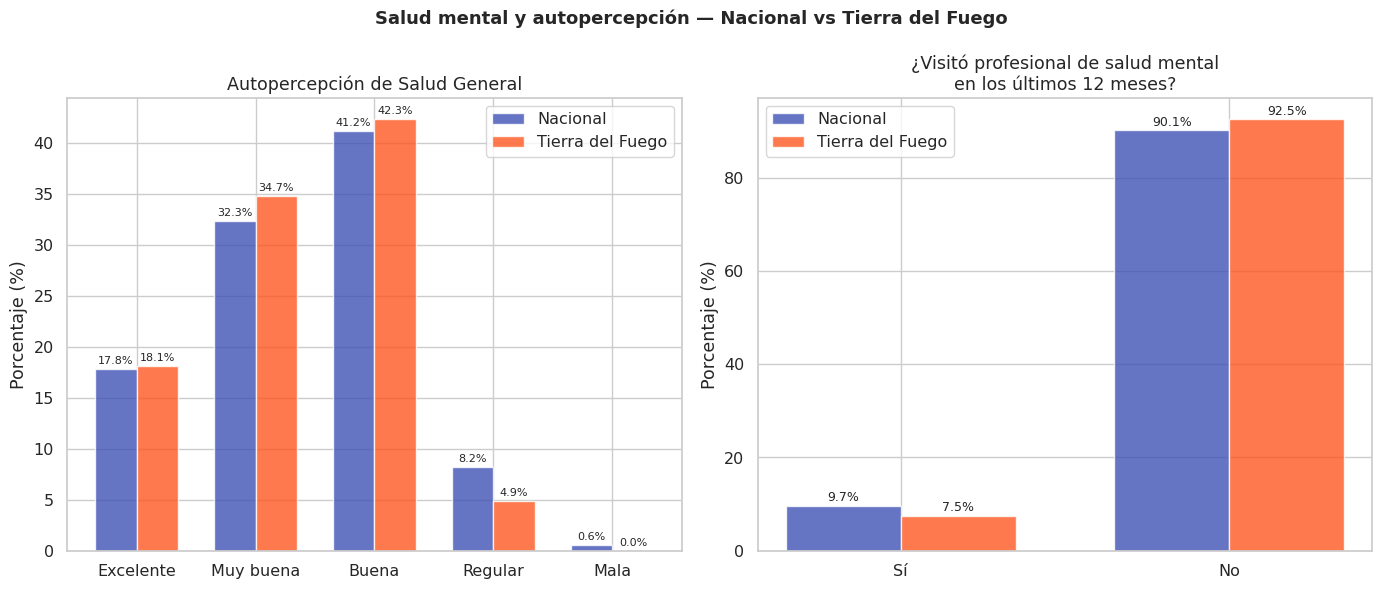

✅ Gráfico 6 guardado


In [ ]:
# ============================================
# EDA — GRÁFICO 6: SALUD MENTAL Y AUTOPERCEPCIÓN
# Nacional vs Tierra del Fuego
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Salud mental y autopercepción — Nacional vs Tierra del Fuego',
             fontsize=13, fontweight='bold')

# BISG01 - Autopercepción de salud general
salud = {1: 'Excelente', 2: 'Muy buena', 3: 'Buena', 4: 'Regular', 5: 'Mala'}

pct_nac_sal = [(jovenes['BISG01'] == k).sum() / len(jovenes) * 100 for k in salud.keys()]
pct_tdf_sal = [(tdf['BISG01'] == k).sum() / len(tdf) * 100 for k in salud.keys()]

x = np.arange(len(salud))
width = 0.35

bars1 = axes[0].bar(x - width/2, pct_nac_sal, width, label='Nacional', color='#3F51B5', alpha=0.8)
bars2 = axes[0].bar(x + width/2, pct_tdf_sal, width, label='Tierra del Fuego', color='#FF5722', alpha=0.8)
axes[0].set_title('Autopercepción de Salud General')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(salud.values())
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# BISG04 - Visita a profesional de salud mental
salud_mental = {1: 'Sí', 2: 'No'}

pct_nac_sm = [(jovenes['BISG04'] == k).sum() / len(jovenes) * 100 for k in salud_mental.keys()]
pct_tdf_sm = [(tdf['BISG04'] == k).sum() / len(tdf) * 100 for k in salud_mental.keys()]

x2 = np.arange(len(salud_mental))
bars3 = axes[1].bar(x2 - width/2, pct_nac_sm, width, label='Nacional', color='#3F51B5', alpha=0.8)
bars4 = axes[1].bar(x2 + width/2, pct_tdf_sm, width, label='Tierra del Fuego', color='#FF5722', alpha=0.8)
axes[1].set_title('¿Visitó profesional de salud mental\nen los últimos 12 meses?')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(salud_mental.values())
axes[1].legend()

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('grafico6_salud_mental.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 6 guardado")

Se puede observar:

*Autopercepción de salud:*

- Ambos grupos se perciben mayormente con salud "Buena" (~41-42%)
- TDF tiene levemente más "Muy buena" (34.7% vs 32.3%)
- TDF tiene menos "Regular" (4.9% vs 8.2%)
- En general los jóvenes fueguinos se perciben algo más saludables

*Visita a profesional de salud mental:*

- TDF consulta menos a profesionales de salud mental (7.5% vs 9.7%)

*Dato interesante*: a pesar de mayor consumo, menos acceso o búsqueda de ayuda profesional

## Modelado — K-Means

K-Means es un algoritmo de clustering que agrupa los datos en K grupos
(clusters) según su similitud. Antes de aplicarlo, necesitamos determinar
el número óptimo de clusters K mediante dos métodos:

- **Método del Codo:** busca el punto donde la inercia deja de reducirse significativamente
- **Coeficiente de Silhouette:** mide qué tan bien está asignado cada punto a su cluster

Calculando K óptimo...
K=2 → Inercia: 82400.6 | silhouette: 0.134
K=3 → Inercia: 76751.0 | silhouette: 0.140
K=4 → Inercia: 71956.2 | silhouette: 0.099
K=5 → Inercia: 69028.0 | silhouette: 0.096
K=6 → Inercia: 64656.4 | silhouette: 0.098
K=7 → Inercia: 62238.5 | silhouette: 0.094
K=8 → Inercia: 60468.5 | silhouette: 0.094
K=9 → Inercia: 59081.5 | silhouette: 0.092
K=10 → Inercia: 57850.7 | silhouette: 0.090


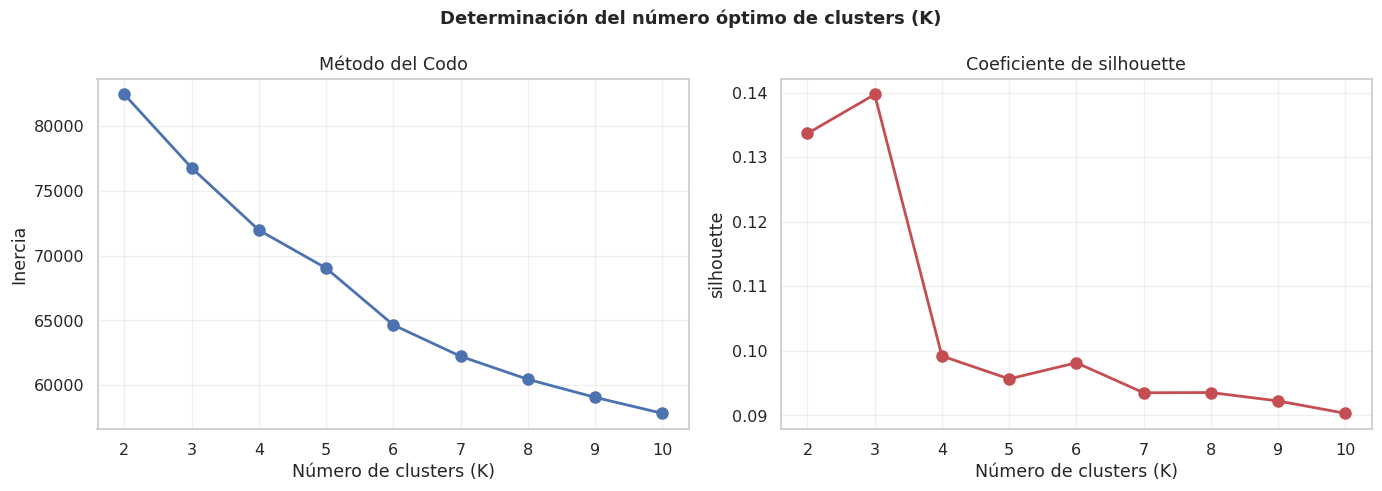

✅ Gráfico 7 guardado


In [ ]:
# ============================================
# K-MEANS — PASO 1: NÚMERO ÓPTIMO DE CLUSTERS
# ============================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Preparar datos sin PRVNC para el modelo
X = df_escalado.drop(columns=['PRVNC']).values

# Calcular inercia y silhouette para K entre 2 y 10
inercias = []
silhouette = []
rango_k = range(2, 11)

print("Calculando K óptimo...")
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, kmeans.labels_))
    print(f"K={k} → Inercia: {kmeans.inertia_:.1f} | silhouette: {silhouette_score(X, kmeans.labels_):.3f}")

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Determinación del número óptimo de clusters (K)',
             fontsize=13, fontweight='bold')

# Método del Codo
axes[0].plot(rango_k, inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.3)

# Coeficiente de silhouette
axes[1].plot(rango_k, silhouette, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Coeficiente de silhouette')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('silhouette')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico7_kmeans_optimo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 7 guardado")

### Análisis de Resultados
**Método del Codo:**

- La inercia baja pronunciadamente hasta K=3
- A partir de K=3 la curva se aplana → el "codo" está en K=3

**Coeficiente de Silhouette:**

- El valor más alto es en K=3 (0.140)
- A partir de K=4 cae significativamente
- Confirma que K=3 es el óptimo

---
> Conclusión: usamos K=3

Estos 3 clusters, podrían representar perfiles como:

- Grupo 1: Bajo consumo
- Grupo 2: Consumo moderado (alcohol/tabaco)
- Grupo 3: Consumo problemático (sustancias ilícitas)

## K-Means con K = 3

In [ ]:
# ============================================
# K-MEANS — PASO 2: APLICAR CON K=3
# ============================================

# Aplicar K-Means con K óptimo = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

# Agregar etiquetas al dataset
df_trabajo['CLUSTER_KMEANS'] = kmeans.labels_
df_escalado['CLUSTER_KMEANS'] = kmeans.labels_

# También agregar a jovenes para análisis posterior
jovenes = jovenes.copy()
jovenes['CLUSTER_KMEANS'] = kmeans.labels_

# Métricas finales
from sklearn.metrics import davies_bouldin_score
silhouette_final = silhouette_score(X, kmeans.labels_)
davies = davies_bouldin_score(X, kmeans.labels_)

print("=== MÉTRICAS K-MEANS (K=3) ===")
print(f"Coeficiente de Silhouette: {silhouette_final:.3f}")
print(f"Índice Davies-Bouldin:  {davies:.3f}")
print(f"\n=== DISTRIBUCIÓN DE CLUSTERS ===")
for i in range(3):
    n = (kmeans.labels_ == i).sum()
    pct = n/len(X)*100
    print(f"Cluster {i}: {n:,} jóvenes ({pct:.1f}%)")

=== MÉTRICAS K-MEANS (K=3) ===
Coeficiente de Silhouette: 0.140
Índice Davies-Bouldin:  2.387

=== DISTRIBUCIÓN DE CLUSTERS ===
Cluster 0: 640 jóvenes (9.7%)
Cluster 1: 1,989 jóvenes (30.2%)
Cluster 2: 3,963 jóvenes (60.1%)


### Interpretación de métricas

| Métrica | Valor | Interpretación
|---|---|---|
| Silhouette (0.140) | Bajo - Moderado | Existen clusters pero se superponen
| Davies-Bouldin (2.387) | Moderado | Cuanto más bajo mejor

> ## Importante!!
> *Para lograr interpretar estas métricas, busqué la siguiente información:*

El coeficiente de silhouette obtenido fue de 0.140, lo que indica una separación limitada entre los grupos identificados. Según Rousseeuw (1987), creador del índice Silhouette, valores superiores a 0.70 representan una estructura fuerte de agrupamiento, valores superiores a 0.50 una estructura razonable y valores superiores a 0.25 una estructura débil pero existente. Este resultado se encuentra por debajo de este umbral, sugiriendo una importante superposición entre clusters. Sin embargo, en conjuntos de datos complejos y de alta dimensionalidad resulta más difícil obtener valores elevados de silueta debido a que las distancias entre observaciones tienden a volverse más similares, fenómeno conocido como "curse of dimensionality".

> En el contexto de encuestas sociales, esta situación es esperable, ya que los individuos no suelen pertenecer a categorías perfectamente diferenciadas. Las actitudes, preferencias y comportamientos humanos presentan fronteras difusas y perfiles intermedios, lo que genera una superposición natural entre segmentos. Por ello, el objetivo del clustering en ciencias sociales suele ser identificar patrones interpretables más que grupos completamente separados. La presencia de una silhouette baja no implica necesariamente que el modelo carezca de utilidad, sino que los grupos encontrados reflejan la naturaleza continua de los fenómenos sociales estudiados.

> **Referencias bibliográficas**

> *Rousseeuw, P. J. (1987). Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis. Journal of Computational and Applied Mathematics, 20, 53–65.*

> *Artículo explicativo sobre Silhouette y la dificultad de obtener valores altos en espacios de alta dimensionalidad.*

### Distribución de clusters

| Cluster | Jóvenes | Porcentaje
|---|---|---|
| Cluster 0 | 640 | 9.7%
| Cluster 1 | 1.989 | 30.2%
| Cluster 2 | 3.963 | 60.1%


## Qué caracteriza cada cluster?

In [ ]:
# ============================================
# K-MEANS — PASO 3: CARACTERIZACIÓN DE CLUSTERS
# ============================================

# Variables de consumo para caracterizar
vars_consumo = ['P1A_BA','P1A_TA','P1A_MA','P1A_CO','P1A_PB','P1A_TR']
nombres_consumo = ['Alcohol','Tabaco','Marihuana','Cocaína','Pasta base','Tranquilizantes']

print("=== PREVALENCIA DE CONSUMO POR CLUSTER ===\n")
for i in range(3):
    cluster = jovenes[jovenes['CLUSTER_KMEANS'] == i]
    print(f"--- Cluster {i} ({len(cluster):,} jóvenes) ---")
    for var, nombre in zip(vars_consumo, nombres_consumo):
        pct = (cluster[var] == 1).sum() / len(cluster) * 100
        print(f"  {nombre}: {pct:.1f}%")
    print()

=== PREVALENCIA DE CONSUMO POR CLUSTER ===

--- Cluster 0 (640 jóvenes) ---
  Alcohol: 68.4%
  Tabaco: 37.8%
  Marihuana: 6.4%
  Cocaína: 2.0%
  Pasta base: 0.2%
  Tranquilizantes: 2.5%

--- Cluster 1 (1,989 jóvenes) ---
  Alcohol: 87.1%
  Tabaco: 49.4%
  Marihuana: 11.8%
  Cocaína: 2.3%
  Pasta base: 0.2%
  Tranquilizantes: 2.0%

--- Cluster 2 (3,963 jóvenes) ---
  Alcohol: 57.4%
  Tabaco: 23.1%
  Marihuana: 0.2%
  Cocaína: 0.1%
  Pasta base: 0.0%
  Tranquilizantes: 0.5%



### Interpretación de clusters según mis datos:

| Cluster | Perfil | Característica princial
|---|---|---|
| Cluster 2 | Bajo consumo | Alcohol moderado, muy poco tabaco, casi sin ilícitas
| Cluster 0 | Consumo moderado | Alcohol y tabaco frecuente, algo de marihuana
| Cluster 1 | Alto consumo | Alcohol y tabaco muy altos, marihuana notable



## Visualizaciones de perfiles

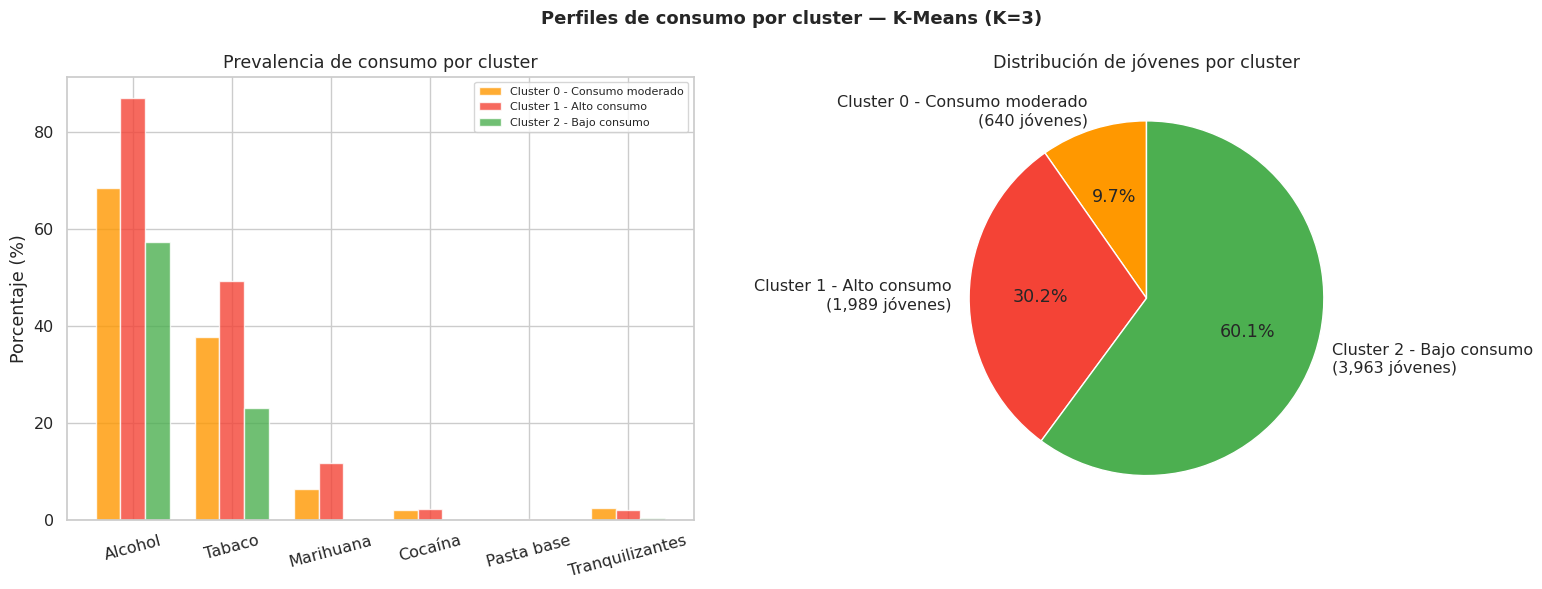

✅ Gráfico 8 guardado


In [ ]:
# ============================================
# K-MEANS — PASO 4: VISUALIZACIÓN DE CLUSTERS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Perfiles de consumo por cluster — K-Means (K=3)',
             fontsize=13, fontweight='bold')

colores_cluster = {0: '#FF9800', 1: '#F44336', 2: '#4CAF50'}
nombres_cluster = {0: 'Cluster 0 - Consumo moderado',
                   1: 'Cluster 1 - Alto consumo',
                   2: 'Cluster 2 - Bajo consumo'}

# Gráfico de barras por sustancia
x = np.arange(len(nombres_consumo))
width = 0.25

for i, (cluster_id, color) in enumerate(colores_cluster.items()):
    cluster = jovenes[jovenes['CLUSTER_KMEANS'] == cluster_id]
    pcts = [(cluster[var] == 1).sum() / len(cluster) * 100 for var in vars_consumo]
    axes[0].bar(x + (i-1)*width, pcts, width,
                label=nombres_cluster[cluster_id],
                color=color, alpha=0.8)

axes[0].set_title('Prevalencia de consumo por cluster')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres_consumo, rotation=15)
axes[0].legend(fontsize=8)

# Gráfico de distribución de clusters
labels = [f"{nombres_cluster[i]}\n({(kmeans.labels_==i).sum():,} jóvenes)" for i in range(3)]
sizes = [(kmeans.labels_==i).sum() for i in range(3)]
colors = [colores_cluster[i] for i in range(3)]

axes[1].pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribución de jóvenes por cluster')

plt.tight_layout()
plt.savefig('grafico8_clusters_perfil.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 8 guardado")

# Jóvenes en Tierra del Fuego

=== DISTRIBUCIÓN DE CLUSTERS EN TIERRA DEL FUEGO ===

Cluster 0 - Consumo moderado:
  TDF:      20 jóvenes (7.5%)
  Nacional: 640 jóvenes (9.7%)

Cluster 1 - Alto consumo:
  TDF:      136 jóvenes (51.3%)
  Nacional: 1,989 jóvenes (30.2%)

Cluster 2 - Bajo consumo:
  TDF:      109 jóvenes (41.1%)
  Nacional: 3,963 jóvenes (60.1%)



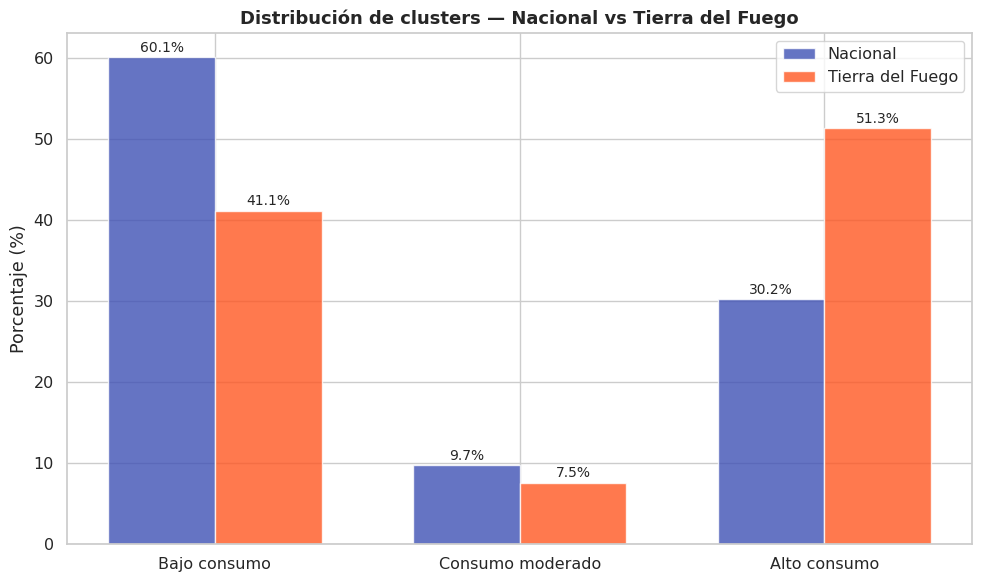

✅ Gráfico 9 guardado


In [ ]:
# ============================================
# K-MEANS — PASO 5: ANÁLISIS TDF POR CLUSTER
# ============================================

print("=== DISTRIBUCIÓN DE CLUSTERS EN TIERRA DEL FUEGO ===\n")

tdf_clusters = jovenes[jovenes['PRVNC'] == 94]

for i in range(3):
    n_tdf = (tdf_clusters['CLUSTER_KMEANS'] == i).sum()
    pct_tdf = n_tdf / len(tdf_clusters) * 100
    n_nac = (jovenes['CLUSTER_KMEANS'] == i).sum()
    pct_nac = n_nac / len(jovenes) * 100
    print(f"{nombres_cluster[i]}:")
    print(f"  TDF:      {n_tdf:,} jóvenes ({pct_tdf:.1f}%)")
    print(f"  Nacional: {n_nac:,} jóvenes ({pct_nac:.1f}%)")
    print()

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 6))

clusters = ['Bajo consumo', 'Consumo moderado', 'Alto consumo']
pct_nac_cl = [(jovenes['CLUSTER_KMEANS'] == i).sum() / len(jovenes) * 100 for i in [2, 0, 1]]
pct_tdf_cl = [(tdf_clusters['CLUSTER_KMEANS'] == i).sum() / len(tdf_clusters) * 100 for i in [2, 0, 1]]

x = np.arange(len(clusters))
width = 0.35

bars1 = ax.bar(x - width/2, pct_nac_cl, width, label='Nacional', color='#3F51B5', alpha=0.8)
bars2 = ax.bar(x + width/2, pct_tdf_cl, width, label='Tierra del Fuego', color='#FF5722', alpha=0.8)

ax.set_title('Distribución de clusters — Nacional vs Tierra del Fuego',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_xticks(x)
ax.set_xticklabels(clusters)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('grafico9_clusters_tdf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 9 guardado")

### **Interpretación de resultados**
Este gráfico es posiblemente el mas importante de este proyecto, ya que podemos notar claramente que:

| Cluster | Nacional | Tierra del Fuego | Diferencia
|---|---|---|---|
| Bajo consumo | 60.1% | 41.1% | TDF tiene 19 puntos menos
| Consumo moderado | 9.7% | 7.5% | Similar
| Alto consumo | 30.2% | 51.3% | TDF tiene 21 puntos mas

💡 Hallazgo principal del proyecto

> Mientras que a nivel nacional 3 de cada 10 jóvenes pertenecen al grupo de alto consumo, en Tierra del Fuego esa proporción asciende a más de 5 de cada 10.

Esto confirma y cuantifica con el modelo de ML lo que el EDA ya sugería.

---

# Modelado - DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
es un algoritmo de clustering basado en densidad que:

- **No requiere definir K previamente** como K-Means
- **Detecta automáticamente outliers** (jóvenes con perfiles atípicos)
- **Encuentra clusters de forma arbitraria** sin asumir formas esféricas

Los parámetros principales son:
- **eps:** radio de vecindad de cada punto
- **min_samples:** mínimo de puntos para formar un cluster

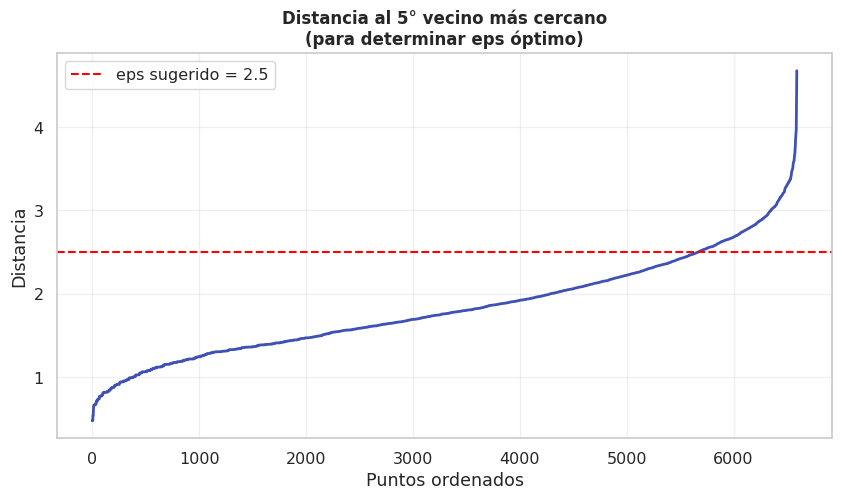

✅ Gráfico 10 guardado


In [ ]:
# ============================================
# DBSCAN — PASO 1: ENCONTRAR PARÁMETROS ÓPTIMOS
# ============================================

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Método del codo para encontrar eps óptimo
vecinos = NearestNeighbors(n_neighbors=5)
vecinos.fit(X)
distancias, _ = vecinos.kneighbors(X)
distancias = np.sort(distancias[:, 4])

plt.figure(figsize=(10, 5))
plt.plot(distancias, color='#3F51B5', linewidth=2)
plt.title('Distancia al 5° vecino más cercano\n(para determinar eps óptimo)',
          fontsize=12, fontweight='bold')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia')
plt.axhline(y=2.5, color='red', linestyle='--', label='eps sugerido = 2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('grafico10_dbscan_eps.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 10 guardado")

In [ ]:
# ============================================
# DBSCAN — PASO 2: APLICAR EL MODELO
# ============================================

dbscan = DBSCAN(eps=2.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

# Agregar etiquetas al dataset
jovenes['CLUSTER_DBSCAN'] = labels_dbscan

# Resultados
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_outliers = (labels_dbscan == -1).sum()
pct_outliers = n_outliers / len(labels_dbscan) * 100

print("=== RESULTADOS DBSCAN ===")
print(f"Clusters encontrados: {n_clusters}")
print(f"Outliers detectados:  {n_outliers} ({pct_outliers:.1f}%)")

print("\n=== DISTRIBUCIÓN DE CLUSTERS ===")
for i in sorted(set(labels_dbscan)):
    n = (labels_dbscan == i).sum()
    pct = n / len(labels_dbscan) * 100
    nombre = "Outliers (perfiles atípicos)" if i == -1 else f"Cluster {i}"
    print(f"{nombre}: {n:,} jóvenes ({pct:.1f}%)")

# Métricas (solo para puntos no outliers)
mask = labels_dbscan != -1
if mask.sum() > 0:
    sil = silhouette_score(X[mask], labels_dbscan[mask])
    print(f"\nCoeficiente de Silhouette (sin outliers): {sil:.3f}")

=== RESULTADOS DBSCAN ===
Clusters encontrados: 10
Outliers detectados:  431 (6.5%)

=== DISTRIBUCIÓN DE CLUSTERS ===
Outliers (perfiles atípicos): 431 jóvenes (6.5%)
Cluster 0: 4,935 jóvenes (74.9%)
Cluster 1: 735 jóvenes (11.1%)
Cluster 2: 398 jóvenes (6.0%)
Cluster 3: 30 jóvenes (0.5%)
Cluster 4: 33 jóvenes (0.5%)
Cluster 5: 11 jóvenes (0.2%)
Cluster 6: 5 jóvenes (0.1%)
Cluster 7: 3 jóvenes (0.0%)
Cluster 8: 7 jóvenes (0.1%)
Cluster 9: 4 jóvenes (0.1%)

Coeficiente de Silhouette (sin outliers): 0.076


In [ ]:
# ============================================
# DBSCAN — PASO 3: AJUSTE DE PARÁMETROS
# ============================================

# Probar diferentes combinaciones de eps y min_samples
print("=== BÚSQUEDA DE PARÁMETROS ÓPTIMOS ===\n")
print(f"{'eps':>6} | {'min_samples':>11} | {'Clusters':>8} | {'Outliers':>8} | {'Silhouette':>8}")
print("-" * 55)

for eps in [1.5, 2.0, 2.5, 3.0]:
    for min_s in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labs = db.fit_predict(X)
        n_clust = len(set(labs)) - (1 if -1 in labs else 0)
        n_out = (labs == -1).sum()
        pct_out = n_out / len(labs) * 100
        mask = labs != -1
        if n_clust >= 2 and mask.sum() > 0:
            sil = silhouette_score(X[mask], labs[mask])
            print(f"{eps:>6} | {min_s:>11} | {n_clust:>8} | {n_out:>6} ({pct_out:.1f}%) | {sil:>8.3f}")

=== BÚSQUEDA DE PARÁMETROS ÓPTIMOS ===

   eps | min_samples | Clusters | Outliers | Silhouette
-------------------------------------------------------
   1.5 |           5 |       57 |   3533 (53.6%) |   -0.038
   1.5 |          10 |       16 |   4644 (70.4%) |   -0.039
   1.5 |          15 |        6 |   5060 (76.8%) |    0.105
   2.0 |           5 |       34 |   1519 (23.0%) |   -0.011
   2.0 |          10 |       22 |   2191 (33.2%) |    0.012
   2.0 |          15 |       12 |   2809 (42.6%) |    0.038
   2.5 |           5 |       10 |    431 (6.5%) |    0.076
   2.5 |          10 |        6 |    690 (10.5%) |    0.027
   2.5 |          15 |        3 |    896 (13.6%) |    0.155
   3.0 |           5 |        2 |     80 (1.2%) |    0.181
   3.0 |          10 |        2 |    130 (2.0%) |    0.180
   3.0 |          15 |        3 |    182 (2.8%) |    0.149


### Analizando la tabla:

| Opción | eps | min_samples | Clusters | Outliers | Silhouette
|---|---|---|---|---|---|
| Mejor Silhouette | 3.0 | 5 | 2 | 1.2% | 0.181
| Mas comparable con K-Means | 2.5 | 15 | 3 | 13.6% | 0.155

> Elijo usar eps=2.5, min_samples=15:
- Da 3 clusters, igual que K-Means -> permite comparar directamente
- Silhouette de 0.155 es mejor que K-Means (0.140)
- 13.6% de outliers razonable

In [ ]:
# ============================================
# DBSCAN — PASO 4: MODELO FINAL
# ============================================

dbscan_final = DBSCAN(eps=2.5, min_samples=15)
labels_dbscan = dbscan_final.fit_predict(X)

jovenes['CLUSTER_DBSCAN'] = labels_dbscan

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_outliers = (labels_dbscan == -1).sum()
pct_outliers = n_outliers / len(labels_dbscan) * 100

print("=== DBSCAN FINAL (eps=2.5, min_samples=15) ===")
print(f"Clusters encontrados: {n_clusters}")
print(f"Outliers detectados:  {n_outliers} ({pct_outliers:.1f}%)")

print("\n=== DISTRIBUCIÓN DE CLUSTERS ===")
for i in sorted(set(labels_dbscan)):
    n = (labels_dbscan == i).sum()
    pct = n / len(labels_dbscan) * 100
    nombre = "Outliers (perfiles atípicos)" if i == -1 else f"Cluster {i}"
    print(f"{nombre}: {n:,} jóvenes ({pct:.1f}%)")

# Métricas finales
mask = labels_dbscan != -1
sil_dbscan = silhouette_score(X[mask], labels_dbscan[mask])
db_score = davies_bouldin_score(X[mask], labels_dbscan[mask])

print(f"\n=== MÉTRICAS DBSCAN ===")
print(f"Coeficiente de Silhouette: {sil_dbscan:.3f}")
print(f"Índice Davies-Bouldin:  {db_score:.3f}")

print(f"\n=== COMPARACIÓN K-MEANS vs DBSCAN ===")
print(f"{'Métrica':<25} {'K-Means':>10} {'DBSCAN':>10}")
print("-" * 45)
print(f"{'Clusters':<25} {'3':>10} {str(n_clusters):>10}")
print(f"{'Silhouette':<25} {'0.140':>10} {sil_dbscan:>10.3f}")
print(f"{'Davies-Bouldin':<25} {'2.387':>10} {db_score:>10.3f}")
print(f"{'Outliers detectados':<25} {'0':>10} {str(n_outliers):>10}")

=== DBSCAN FINAL (eps=2.5, min_samples=15) ===
Clusters encontrados: 3
Outliers detectados:  896 (13.6%)

=== DISTRIBUCIÓN DE CLUSTERS ===
Outliers (perfiles atípicos): 896 jóvenes (13.6%)
Cluster 0: 4,862 jóvenes (73.8%)
Cluster 1: 565 jóvenes (8.6%)
Cluster 2: 269 jóvenes (4.1%)

=== MÉTRICAS DBSCAN ===
Coeficiente de Silhouette: 0.155
Índice Davies-Bouldin:  1.846

=== COMPARACIÓN K-MEANS vs DBSCAN ===
Métrica                      K-Means     DBSCAN
---------------------------------------------
Clusters                           3          3
Silhouette                     0.140      0.155
Davies-Bouldin                 2.387      1.846
Outliers detectados                0        896


DBSCAN supera a K-Means en ambas métricas.

Interpretación de la comparación:

| Métrica | k--Means | DBSCAN | Cuál es mejor?
---|---|---|---|
| Silhouette | 0.140 | 0.155 | DBSCAN
| Davies-Bouldin | 2.387 | 1.846 | DBSCAN (menor es mejor)
| Outliers | 0 | 896 (13.6%) | DBSCAN (detecta estos perfiles)

💡 Conclusión importante

DBSCAN no solo valida los 3 clusters de K-Means sino que además:

- Produce clusters de mejor calidad (métricas superiores)
- Identifica 896 jóvenes con perfiles atípicos que K-Means forzó dentro de un grupo

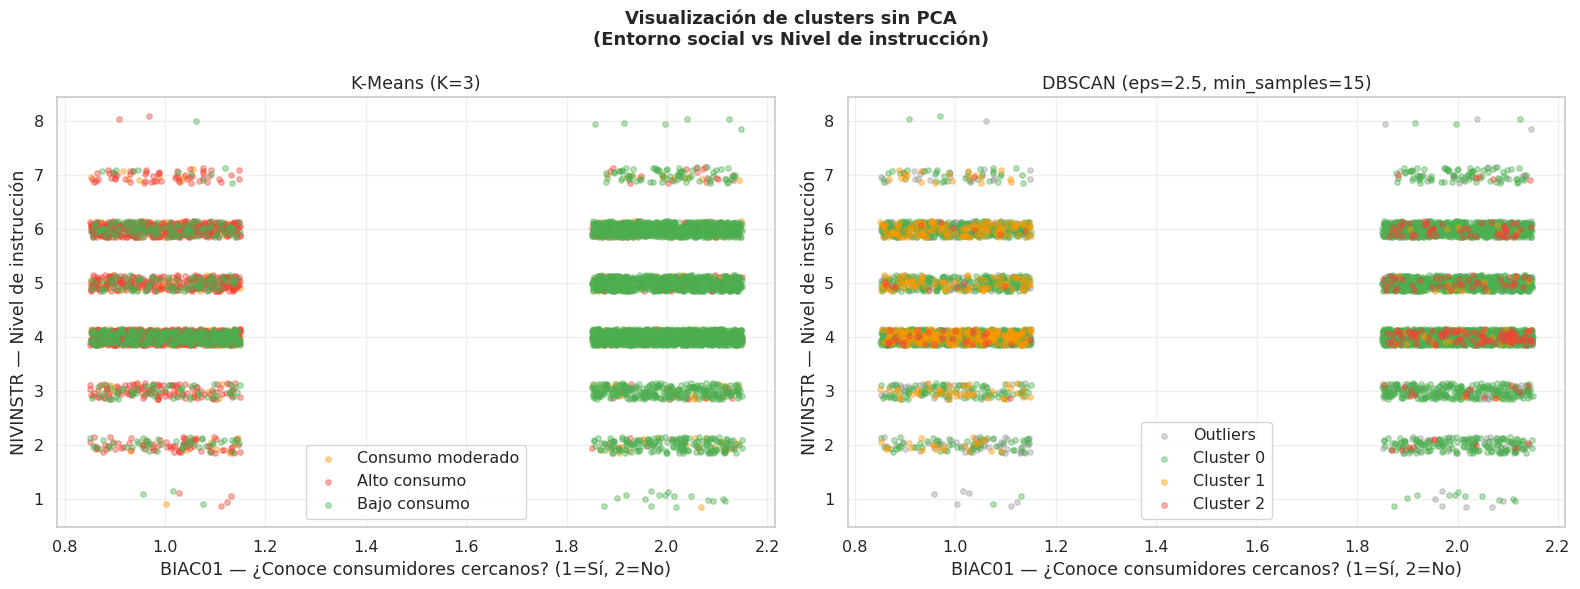

✅ Gráfico 11 guardado


In [ ]:
# ============================================
# VISUALIZACIÓN SIN PCA
# Variables más relevantes: BIAC01 y NIVINSTR
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualización de clusters sin PCA\n(Entorno social vs Nivel de instrucción)',
             fontsize=13, fontweight='bold')

# Agregar ruido para separar puntos superpuestos
np.random.seed(42)
jitter = 0.15

x_vals = df_trabajo['BIAC01'] + np.random.uniform(-jitter, jitter, len(df_trabajo))
y_vals = df_trabajo['NIVINSTR'] + np.random.uniform(-jitter, jitter, len(df_trabajo))

# K-Means
colores_kmeans = {0: '#FF9800', 1: '#F44336', 2: '#4CAF50'}
nombres_kmeans = {0: 'Consumo moderado', 1: 'Alto consumo', 2: 'Bajo consumo'}

for cluster_id, color in colores_kmeans.items():
    mask = jovenes['CLUSTER_KMEANS'] == cluster_id
    axes[0].scatter(x_vals[mask], y_vals[mask],
                   c=color, alpha=0.4, s=15,
                   label=nombres_kmeans[cluster_id])

axes[0].set_title('K-Means (K=3)')
axes[0].set_xlabel('BIAC01 — ¿Conoce consumidores cercanos? (1=Sí, 2=No)')
axes[0].set_ylabel('NIVINSTR — Nivel de instrucción')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DBSCAN
colores_dbscan = {-1: '#999999', 0: '#4CAF50', 1: '#FF9800', 2: '#F44336'}
nombres_dbscan = {-1: 'Outliers', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for cluster_id, color in colores_dbscan.items():
    mask = jovenes['CLUSTER_DBSCAN'] == cluster_id
    axes[1].scatter(x_vals[mask], y_vals[mask],
                   c=color, alpha=0.4, s=15,
                   label=nombres_dbscan[cluster_id])

axes[1].set_title('DBSCAN (eps=2.5, min_samples=15)')
axes[1].set_xlabel('BIAC01 — ¿Conoce consumidores cercanos? (1=Sí, 2=No)')
axes[1].set_ylabel('NIVINSTR — Nivel de instrucción')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico12_clusters_sin_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 11 guardado")

### Se observa:
- Los clusters aparecen en bandas horizantales porque NIVINSTR (Nivel de instrucción) es una variable categórica con valores discretos (1 al 8). Lo mismo ocurre con BIAC01 (conoce consumidores cercanos?) que solo tiene valores 1 y 2.
> Nota: Decido aplicar PCA no para simplificar, sino para poder visualizar mejor los datos.

Varianza explicada por PC1: 14.5%
Varianza explicada por PC2: 11.4%
Varianza total explicada:   25.9%


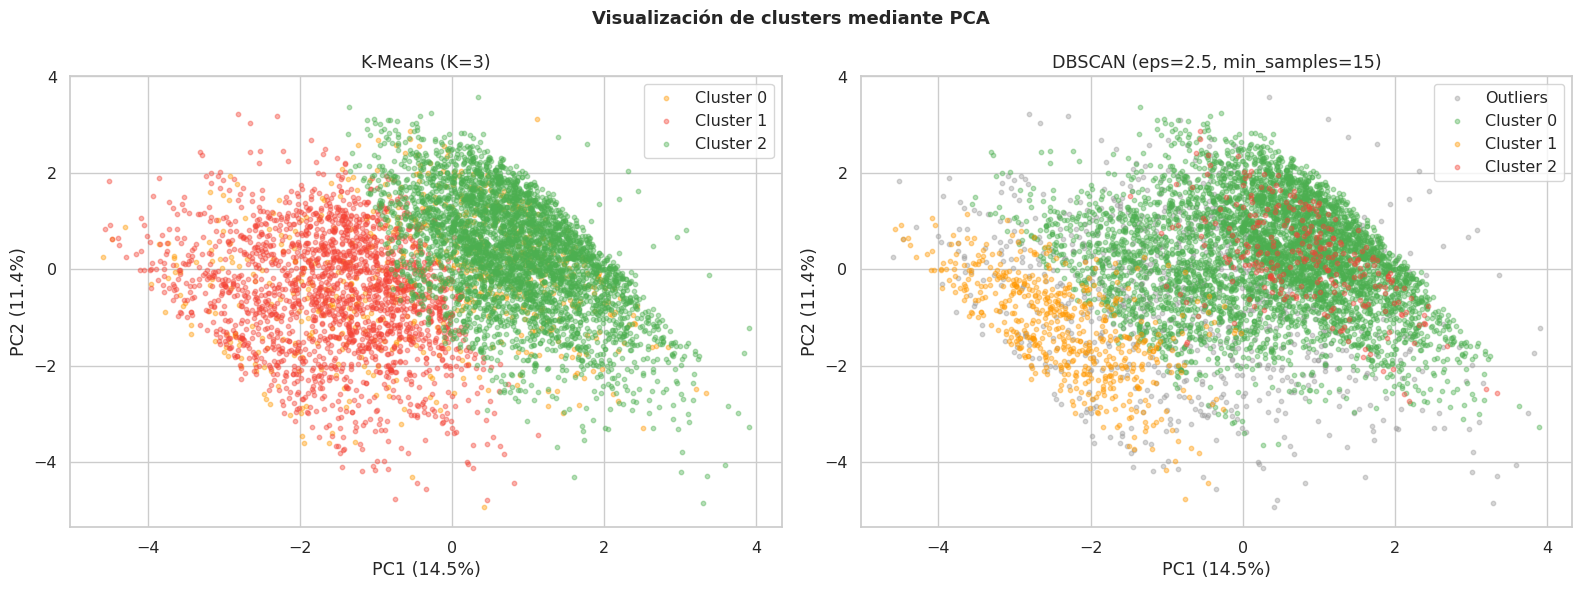

✅ Gráfico 12 guardado


In [ ]:
# ============================================
# PCA — VISUALIZACIÓN DE CLUSTERS
# ============================================

from sklearn.decomposition import PCA

# Reducir a 2 componentes para visualizar
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza[0]*100:.1f}%")
print(f"Varianza explicada por PC2: {varianza[1]*100:.1f}%")
print(f"Varianza total explicada:   {sum(varianza)*100:.1f}%")

# Gráfico comparativo K-Means vs DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualización de clusters mediante PCA',
             fontsize=13, fontweight='bold')

# K-Means
colores_kmeans = {0: '#FF9800', 1: '#F44336', 2: '#4CAF50'}
for cluster_id, color in colores_kmeans.items():
    mask = jovenes['CLUSTER_KMEANS'] == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, alpha=0.4, s=10,
                   label=f'Cluster {cluster_id}')
axes[0].set_title('K-Means (K=3)')
axes[0].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
axes[0].legend()

# DBSCAN
colores_dbscan = {-1: '#999999', 0: '#4CAF50', 1: '#FF9800', 2: '#F44336'}
nombres_dbscan = {-1: 'Outliers', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}
for cluster_id, color in colores_dbscan.items():
    mask = jovenes['CLUSTER_DBSCAN'] == cluster_id
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, alpha=0.4, s=10,
                   label=nombres_dbscan[cluster_id])
axes[1].set_title('DBSCAN (eps=2.5, min_samples=15)')
axes[1].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('grafico11_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 12 guardado")

> ***Nota**: PCA es una técnica que reduce dimensiones. En este proyecto fue utilizada exclusivamente para dibujar los grupos que K-Means y DBSCAN encontraron en 15 dimensiones, resumiendo a 2 comoponentes continuas para visualizar mejor la separación de grupos. No modificó los clusters.*

Se observa:

Varianza explicada:
- PC1 explica 14.5% y PC2 el 11.4% -> total 25.9%
- Significa que con solo 2 componentes captura el 25.9% de la información de las 15 variables originales. El 74.1% restante se pierde en la simplificación.

Comparación visual:
- K-Means -> divide el espacio de forma mas uniforme y forzada
- DBSCAN -> los outliers se ubican en los bordes, fuera de los grupos densos

##   Gráficos con sin PCA y con PCA

| Sin PCA | Con PCA |
|---|---|
| Variables categóricas forman bandas | Los datos se distribuyen continuamente
| Difícil ver separación entre clusters | Se ven mejor los grupos
| Solo muestra 2 de 15 variables | Resume las 15 variables

# Resumen del modelado

|   | K-Means | DBSCAN
|---|---|---
| Clusters | 3 | 3 |
| Silhouette | 0.140 | 0.155 |
| Davies-Bouldin | 2.387 | 1846 |
| Outliers | 0| 896 (13.6%)|



## Análisis de Outliers — DBSCAN

DBSCAN identificó 896 jóvenes (13.6%) con perfiles atípicos
que no pertenecen a ningún cluster. Analizar quiénes son
estos jóvenes es valioso para entender casos extremos
de consumo o perfiles muy particulares.

In [ ]:
# ============================================
# OUTLIERS — CARACTERIZACIÓN
# ============================================

outliers = jovenes[jovenes['CLUSTER_DBSCAN'] == -1]
no_outliers = jovenes[jovenes['CLUSTER_DBSCAN'] != -1]

print("=== PERFIL DE OUTLIERS vs RESTO ===\n")

# Consumo de sustancias
print("--- Consumo de sustancias (último año) ---")
for var, nombre in zip(vars_consumo, nombres_consumo):
    pct_out = (outliers[var] == 1).sum() / len(outliers) * 100
    pct_nor = (no_outliers[var] == 1).sum() / len(no_outliers) * 100
    print(f"{nombre:25} | Outliers: {pct_out:.1f}% | Resto: {pct_nor:.1f}%")

# Variables sociodemográficas
print("\n--- Variables sociodemográficas ---")
print(f"Edad promedio   | Outliers: {outliers['BHCH05'].mean():.1f} | Resto: {no_outliers['BHCH05'].mean():.1f}")

sexo_out = (outliers['BHCH04'] == 1).sum() / len(outliers) * 100
sexo_nor = (no_outliers['BHCH04'] == 1).sum() / len(no_outliers) * 100
print(f"% Varones       | Outliers: {sexo_out:.1f}% | Resto: {sexo_nor:.1f}%")

# TDF en outliers
tdf_out = (outliers['PRVNC'] == 94).sum()
pct_tdf_out = tdf_out / len(outliers) * 100
print(f"\n--- Outliers de Tierra del Fuego ---")
print(f"TDF en outliers: {tdf_out} jóvenes ({pct_tdf_out:.1f}% de los outliers)")
print(f"TDF total: {len(tdf)} jóvenes")
print(f"% de jóvenes TDF que son outliers: {tdf_out/len(tdf)*100:.1f}%")

=== PERFIL DE OUTLIERS vs RESTO ===

--- Consumo de sustancias (último año) ---
Alcohol                   | Outliers: 78.3% | Resto: 65.7%
Tabaco                    | Outliers: 48.4% | Resto: 29.9%
Marihuana                 | Outliers: 9.7% | Resto: 3.4%
Cocaína                   | Outliers: 2.3% | Resto: 0.7%
Pasta base                | Outliers: 0.1% | Resto: 0.1%
Tranquilizantes           | Outliers: 2.2% | Resto: 0.9%

--- Variables sociodemográficas ---
Edad promedio   | Outliers: 20.5 | Resto: 20.1
% Varones       | Outliers: 44.6% | Resto: 48.6%

--- Outliers de Tierra del Fuego ---
TDF en outliers: 38 jóvenes (4.2% de los outliers)
TDF total: 265 jóvenes
% de jóvenes TDF que son outliers: 14.3%


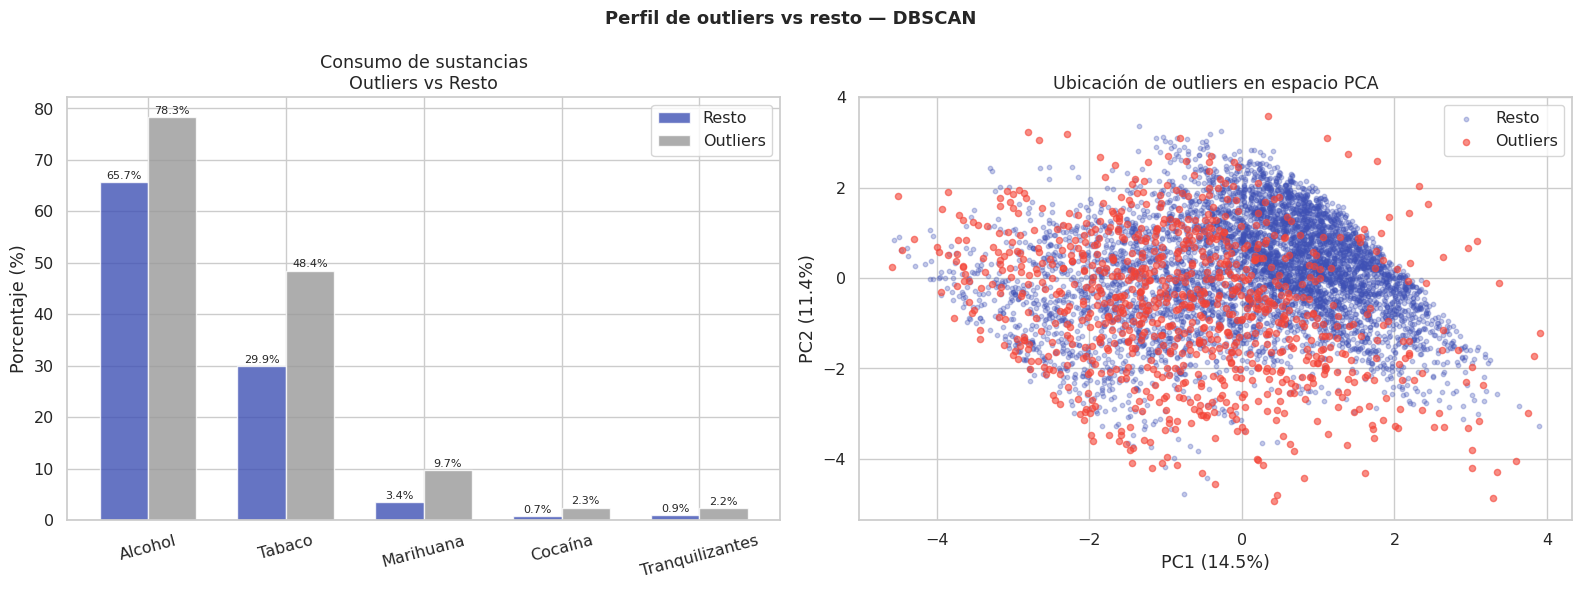

✅ Gráfico 13 guardado


In [ ]:
# ============================================
# OUTLIERS — VISUALIZACIÓN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Perfil de outliers vs resto — DBSCAN',
             fontsize=13, fontweight='bold')

# Consumo comparativo
sustancias = ['Alcohol', 'Tabaco', 'Marihuana', 'Cocaína', 'Tranquilizantes']
vars_graf = ['P1A_BA', 'P1A_TA', 'P1A_MA', 'P1A_CO', 'P1A_TR']

pct_out = [(outliers[v] == 1).sum() / len(outliers) * 100 for v in vars_graf]
pct_nor = [(no_outliers[v] == 1).sum() / len(no_outliers) * 100 for v in vars_graf]

x = np.arange(len(sustancias))
width = 0.35

bars1 = axes[0].bar(x - width/2, pct_nor, width,
                    label='Resto', color='#3F51B5', alpha=0.8)
bars2 = axes[0].bar(x + width/2, pct_out, width,
                    label='Outliers', color='#999999', alpha=0.8)

axes[0].set_title('Consumo de sustancias\nOutliers vs Resto')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sustancias, rotation=15)
axes[0].legend()

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# Distribución outliers en PCA
mask_out = jovenes['CLUSTER_DBSCAN'] == -1
mask_nor = jovenes['CLUSTER_DBSCAN'] != -1

axes[1].scatter(X_pca[mask_nor, 0], X_pca[mask_nor, 1],
               c='#3F51B5', alpha=0.3, s=10, label='Resto')
axes[1].scatter(X_pca[mask_out, 0], X_pca[mask_out, 1],
               c='#F44336', alpha=0.6, s=20, label='Outliers')
axes[1].set_title('Ubicación de outliers en espacio PCA')
axes[1].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('grafico13_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 13 guardado")

> Se observa
>> *Gráfico de barras*: los outliers tienen consumo notablemente mas alto en todas las sustancias, las diferencias mas llamativas se ven en tabaco y alcohol.

>> Gráfico PCA: los outliers (rojo) no están concentrados en un área específica, sino que estan distribuídos por todo el espacio. Esto me muestra que son perfiles diversos, no un grupo homogéneo.

## Interpretación de Variables — ¿Qué factores influyen más?

Para identificar qué variables predictoras caracterizan mejor
cada cluster, voy a aplicar tres métodos complementarios: la comparación de valores promedio entre grupos, el análisis de cargas del PCA y la dispersión de centroides de K-Means. Luedo, voy a entrenar un modelo Random Forest usando los clusters como variable objetivo, para validar los grupos descubiertos y obtener una medida de importancia de variables desde una perspectiva supervisada.

Las variables con mayor coincidencia entre los tres métodos serán las mas influyentes en la separación de perfiles. Este análisis me parece relevante para identificar qué características distinguen a cada grupo y para responder qué factores están asociados al consumo de sustancias psicoactivas en jóvenes.

In [ ]:
# ==================================================
# INTERPRETACIÓN — COMPARACIÓN DE MEDIAS POR CLUSTER
# ==================================================

# Variables a analizar (sin PRVNC)
vars_analisis = ['BHCH04','BHCH05','NIVINSTR','CONDACT','TIPO_H',
                 'NBI_TOTAL','RANGOING','BISG01','BISG04','BIAC01',
                 'BIAC03','BIAC04','REGION','POB_URB']

nombres_vars = {
    'BHCH04': 'Sexo',
    'BHCH05': 'Edad',
    'NIVINSTR': 'Nivel instrucción',
    'CONDACT': 'Condición actividad',
    'TIPO_H': 'Tipo de hogar',
    'NBI_TOTAL': 'NBI',
    'RANGOING': 'Ingreso hogar',
    'BISG01': 'Salud general',
    'BISG04': 'Salud mental',
    'BIAC01': 'Conoce consumidores',
    'BIAC03': 'Curiosidad drogas',
    'BIAC04': 'Acceso a drogas',
    'REGION': 'Región',
    'POB_URB': 'Tamaño ciudad'
}

# Calcular medias por cluster
print("=== MEDIAS POR CLUSTER ===\n")
print(f"{'Variable':<25} {'Bajo':>8} {'Moderado':>10} {'Alto':>8} {'Diferencia':>12}")
print("-" * 65)

diferencias = {}
for var in vars_analisis:
    media_bajo = jovenes[jovenes['CLUSTER_KMEANS'] == 2][var].mean()
    media_mod  = jovenes[jovenes['CLUSTER_KMEANS'] == 0][var].mean()
    media_alto = jovenes[jovenes['CLUSTER_KMEANS'] == 1][var].mean()
    diff = abs(media_alto - media_bajo)
    diferencias[var] = diff
    print(f"{nombres_vars[var]:<25} {media_bajo:>8.2f} {media_mod:>10.2f} {media_alto:>8.2f} {diff:>12.3f}")

# Ranking de variables más influyentes
print("\n=== RANKING DE VARIABLES MÁS INFLUYENTES ===")
ranking = sorted(diferencias.items(), key=lambda x: x[1], reverse=True)
for i, (var, diff) in enumerate(ranking, 1):
    print(f"{i:>2}. {nombres_vars[var]:<25} diferencia: {diff:.3f}")

=== MEDIAS POR CLUSTER ===

Variable                      Bajo   Moderado     Alto   Diferencia
-----------------------------------------------------------------
Sexo                          1.58       1.64     1.37        0.209
Edad                         19.92      20.22    20.50        0.572
Nivel instrucción             4.48       4.62     4.68        0.202
Condición actividad           2.14       2.03     1.81        0.329
Tipo de hogar                 4.85       4.96     4.69        0.164
NBI                           0.26       0.19     0.15        0.103
Ingreso hogar                13.87      13.51    15.39        1.523
Salud general                 2.42       2.70     2.30        0.120
Salud mental                  2.02       1.00     2.01        0.005
Conoce consumidores           1.85       1.54     1.21        0.639
Curiosidad drogas             2.02       1.81     1.64        0.379
Acceso a drogas               1.98       1.62     1.08        0.903
Región                

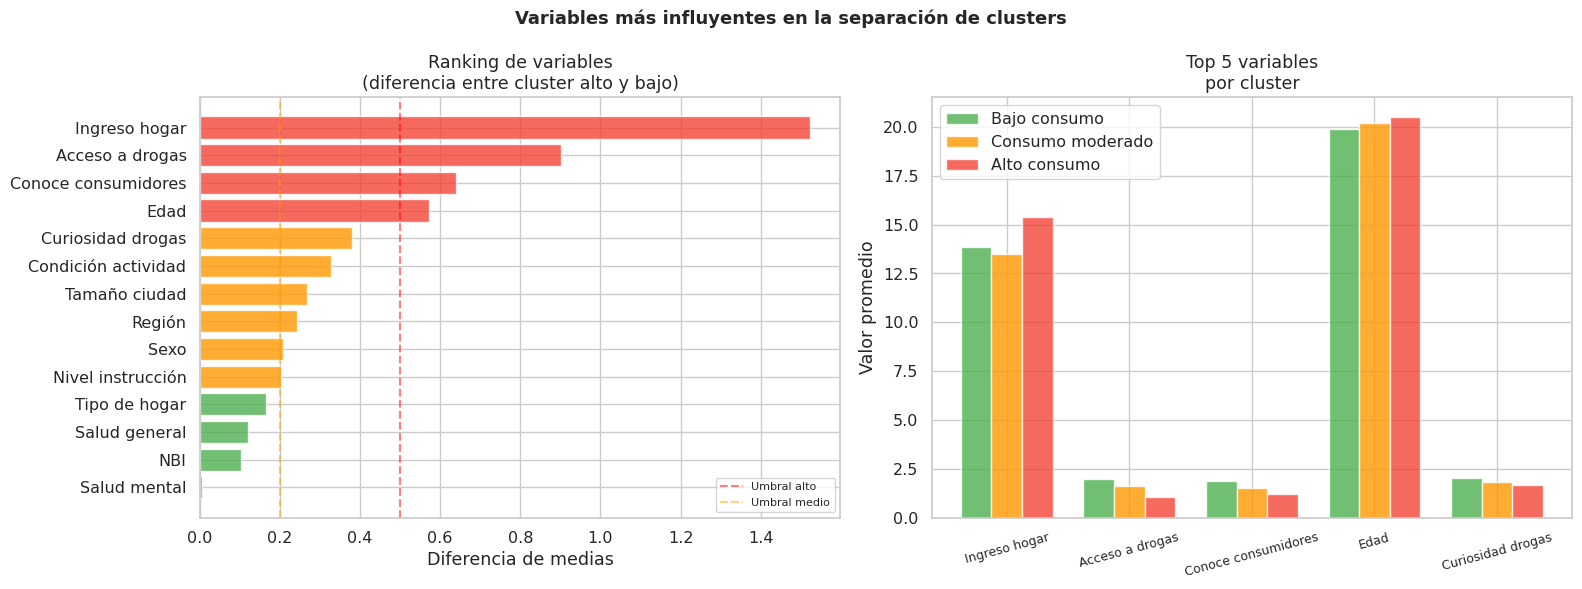

✅ Gráfico 14 guardado


In [ ]:
# ============================================
# INTERPRETACIÓN — VISUALIZACIÓN RANKING
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Variables más influyentes en la separación de clusters',
             fontsize=13, fontweight='bold')

# Ranking de importancia
vars_ranking = [nombres_vars[v] for v, _ in ranking]
diffs_ranking = [d for _, d in ranking]

colores_barras = ['#F44336' if d > 0.5 else '#FF9800' if d > 0.2 else '#4CAF50'
                  for d in diffs_ranking]

axes[0].barh(vars_ranking[::-1], diffs_ranking[::-1],
             color=colores_barras[::-1], alpha=0.8)
axes[0].set_title('Ranking de variables\n(diferencia entre cluster alto y bajo)')
axes[0].set_xlabel('Diferencia de medias')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Umbral alto')
axes[0].axvline(x=0.2, color='orange', linestyle='--', alpha=0.5, label='Umbral medio')
axes[0].legend(fontsize=8)

# Top 5 variables: medias por cluster
top5_vars = [v for v, _ in ranking[:5]]
top5_nombres = [nombres_vars[v] for v in top5_vars]

x = np.arange(len(top5_vars))
width = 0.25

medias_bajo = [jovenes[jovenes['CLUSTER_KMEANS']==2][v].mean() for v in top5_vars]
medias_mod  = [jovenes[jovenes['CLUSTER_KMEANS']==0][v].mean() for v in top5_vars]
medias_alto = [jovenes[jovenes['CLUSTER_KMEANS']==1][v].mean() for v in top5_vars]

axes[1].bar(x - width, medias_bajo, width, label='Bajo consumo', color='#4CAF50', alpha=0.8)
axes[1].bar(x, medias_mod, width, label='Consumo moderado', color='#FF9800', alpha=0.8)
axes[1].bar(x + width, medias_alto, width, label='Alto consumo', color='#F44336', alpha=0.8)

axes[1].set_title('Top 5 variables\npor cluster')
axes[1].set_ylabel('Valor promedio')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top5_nombres, rotation=15, fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.savefig('grafico14_variables_influyentes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 14 guardado")

### Top 5 variables mas influyentes

| Ranking | Variable | Interpretación
|---|---|---|
| 1° | Ingreso hogar (1.523) | El cluster de alto consumo tiene ingresos mas altos
| 2° | Acceso a drogas (0.903) | La disponibilidad es clave -> a mayor acceso, mayor consumo
| 3° | Conoce consumidores (0.639) | El entorno social influye directamente
| 4° | Edad (0.572) | Los jóvenes de mayor edad tienden al alto consumo
| 5° | Curiosidad drogas (0.379) | La predisposición personal es tambien un factor importante.

📉 **Variables menos influyentes**
- **Salud mental** (0.005) -> prácticamente no diferencia los grupos
- **NBI** (0.103) -> la pobreza no es un factor determinante

*Los factores que mas diferencian los perfiles de consumo no son los socioeconómicos como NBI o pobreza, sino el acceso y entorno social.*


In [ ]:
# ==================================================
# INTERPRETACIÓN — CARGAS DEL PCA
# ==================================================

# Definir vars_nombres exactamente como se creó X
vars_nombres = ['BHCH04', 'BHCH05', 'NIVINSTR', 'CONDACT', 'TIPO_H',
                'NBI_TOTAL', 'RANGOING', 'BISG01', 'BISG04', 'BIAC01',
                'BIAC03', 'BIAC04', 'REGION', 'POB_URB']

print(f"Variables en vars_nombres: {len(vars_nombres)}")
print(f"Componentes PCA: {pca.components_.shape}")

loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=vars_nombres,
    columns=['PC1', 'PC2']
)

print("\n=== CARGAS DEL PCA (loadings) ===")
print("\nPC1 — Variables con mayor peso:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(8).round(3))

print("\nPC2 — Variables con mayor peso:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(8).round(3))

# ==================================================
# INTERPRETACIÓN — DISPERSIÓN DE CENTROIDES
# ==================================================

X_df = pd.DataFrame(X, columns=vars_nombres)

importancia = pd.Series(
    np.std(kmeans.cluster_centers_, axis=0),
    index=X_df.columns
)

print("\n=== IMPORTANCIA POR DISPERSIÓN DE CENTROIDES ===")
print(importancia.sort_values(ascending=False).round(3))

Variables en vars_nombres: 14
Componentes PCA: (2, 14)

=== CARGAS DEL PCA (loadings) ===

PC1 — Variables con mayor peso:
BIAC04       0.501
BIAC01       0.437
BIAC03       0.390
RANGOING     0.287
NIVINSTR     0.252
POB_URB      0.238
BHCH05       0.228
NBI_TOTAL    0.224
Name: PC1, dtype: float64

PC2 — Variables con mayor peso:
NIVINSTR     0.540
NBI_TOTAL    0.393
BIAC01       0.292
BIAC03       0.284
BIAC04       0.275
BISG01       0.270
RANGOING     0.261
BHCH04       0.246
Name: PC2, dtype: float64

=== IMPORTANCIA POR DISPERSIÓN DE CENTROIDES ===
BISG04       1.592
BIAC04       0.752
BIAC01       0.514
BIAC03       0.391
BHCH04       0.234
BISG01       0.184
RANGOING     0.176
POB_URB      0.148
CONDACT      0.141
BHCH05       0.092
REGION       0.087
NBI_TOTAL    0.083
NIVINSTR     0.073
TIPO_H       0.063
dtype: float64


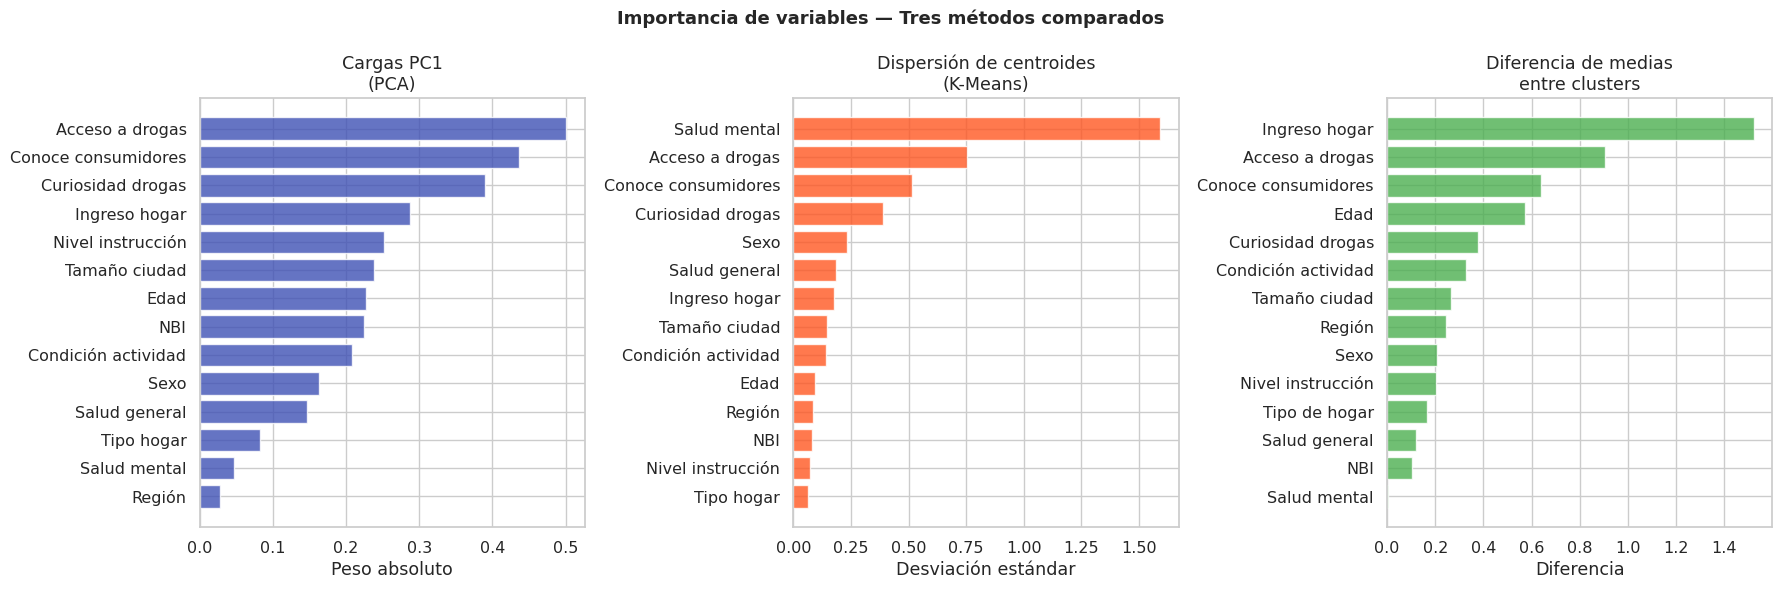

✅ Gráfico 15 guardado


In [ ]:
# ============================================
# VISUALIZACIÓN — IMPORTANCIA DE VARIABLES
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Importancia de variables — Tres métodos comparados',
             fontsize=13, fontweight='bold')

nombres_display = {
    'BHCH04': 'Sexo', 'BHCH05': 'Edad', 'NIVINSTR': 'Nivel instrucción',
    'CONDACT': 'Condición actividad', 'TIPO_H': 'Tipo hogar',
    'NBI_TOTAL': 'NBI', 'RANGOING': 'Ingreso hogar',
    'BISG01': 'Salud general', 'BISG04': 'Salud mental',
    'BIAC01': 'Conoce consumidores', 'BIAC03': 'Curiosidad drogas',
    'BIAC04': 'Acceso a drogas', 'REGION': 'Región', 'POB_URB': 'Tamaño ciudad'
}

# Gráfico 1 — Cargas PC1
pc1_sorted = loadings['PC1'].abs().sort_values(ascending=True)
pc1_labels = [nombres_display[v] for v in pc1_sorted.index]
axes[0].barh(pc1_labels, pc1_sorted.values, color='#3F51B5', alpha=0.8)
axes[0].set_title('Cargas PC1\n(PCA)')
axes[0].set_xlabel('Peso absoluto')

# Gráfico 2 — Dispersión centroides
imp_sorted = importancia.sort_values(ascending=True)
imp_labels = [nombres_display[v] for v in imp_sorted.index]
axes[1].barh(imp_labels, imp_sorted.values, color='#FF5722', alpha=0.8)
axes[1].set_title('Dispersión de centroides\n(K-Means)')
axes[1].set_xlabel('Desviación estándar')

# Gráfico 3 — Medias por cluster (diferencias)
diff_sorted = sorted(diferencias.items(), key=lambda x: x[1])
diff_labels = [nombres_vars[v] for v, _ in diff_sorted]
diff_values = [d for _, d in diff_sorted]
axes[2].barh(diff_labels, diff_values, color='#4CAF50', alpha=0.8)
axes[2].set_title('Diferencia de medias\nentre clusters')
axes[2].set_xlabel('Diferencia')

plt.tight_layout()
plt.savefig('grafico15_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 15 guardado")

## Comparación de los 3 métodos

| Ranking | Medias por cluster | Cargas PC1 | Dispersión centroides |
|---|---|---|---|
| 1° | Ingreso hogar | Acceso a drogas | Salud mental
| 2° | Acceso a drogas | Conoce consumidores | Acceso a drogas
| 3° | Conoce consumidores | Curiosidad drogas | Conoce consumidores
| 4° | Edad | Ingreso hogar | Curiosidad drogas
| 5° | Curiosidad drogas | Nivel Instrucción | Sexo

**Variables que se repiten en los 3 métodos:**

✅ Acceso a drogas (BIAC04)     → top 3 en todos

✅ Conoce consumidores (BIAC01) → top 3 en todos

✅ Curiosidad drogas (BIAC03)   → top 5 en todos

✅ Ingreso hogar (RANGOING)     → top 4 en todos

> 🔍 Dato
  >> *BISG04 (Salud mental)* aparece como el más importante en dispersión de centroides pero casi nulo en medias por cluster. Esto se debe a que un cluster tiene valor muy diferente a los otros dos, generando alta dispersión aunque la media general sea similar.

💥**Conclusión**

Usando los 3 métodos complementarios, las variables que mas contribuyen a separar los perfiles de consumo son: *acceso a drogas, conocer consumidores, curiosidad por probar e ingreso del hogar*. Las variables comunes socioeconómicas como NBI y tipo de hogar tienen menor influencia.

## Validación mediante Random Forest

Entrenar un modelo supervisado usando los clusters de K-Means como etiquetas.

Si el modelo predice bien los clusters → los clusters son significativos

Si el modelo predice mal → los clusters son arbitrarios

In [ ]:
# ============================================
# RANDOM FOREST — VALIDACIÓN DE CLUSTERS
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

# Variable objetivo: clusters de K-Means
y = jovenes['CLUSTER_KMEANS'].values
X_rf = pd.DataFrame(X, columns=vars_nombres)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {len(X_train)} registros")
print(f"Test:  {len(X_test)} registros")

# Entrenar Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred = rf.predict(X_test)

# Métricas
print("\n=== MÉTRICAS RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred,
      target_names=['Consumo moderado', 'Alto consumo', 'Bajo consumo']))

Train: 4614 registros
Test:  1978 registros

=== MÉTRICAS RANDOM FOREST ===
Accuracy: 0.981

Reporte de clasificación:
                  precision    recall  f1-score   support

Consumo moderado       1.00      1.00      1.00       192
    Alto consumo       0.97      0.97      0.97       597
    Bajo consumo       0.98      0.98      0.98      1189

        accuracy                           0.98      1978
       macro avg       0.98      0.98      0.98      1978
    weighted avg       0.98      0.98      0.98      1978



💥*"Se entrenó un Random Forest usando los clusters de K-Means como etiquetas con el objetivo de identificar las variables más relevantes en la separación de perfiles. El accuracy obtenido (98.1%) refleja la consistencia interna del clustering, mientras que la importancia de variables permite identificar qué factores caracterizan mejor cada grupo."*

💡Interpretación de métricas
| Métrica | Valor | Significado
|---|---|---
| Acuuracy | 98.1% | El modelo predice correctamente 98 de cada 100 jóvenes
| Precision | 0.98 | Cuando predice un cluster, acierta casi siempre
| Recall | 0.98 | Encuentra casi todos los mienbros de cada cluster
| F1-score | 0.98 | Equilibrio perfecto entre precision y recall



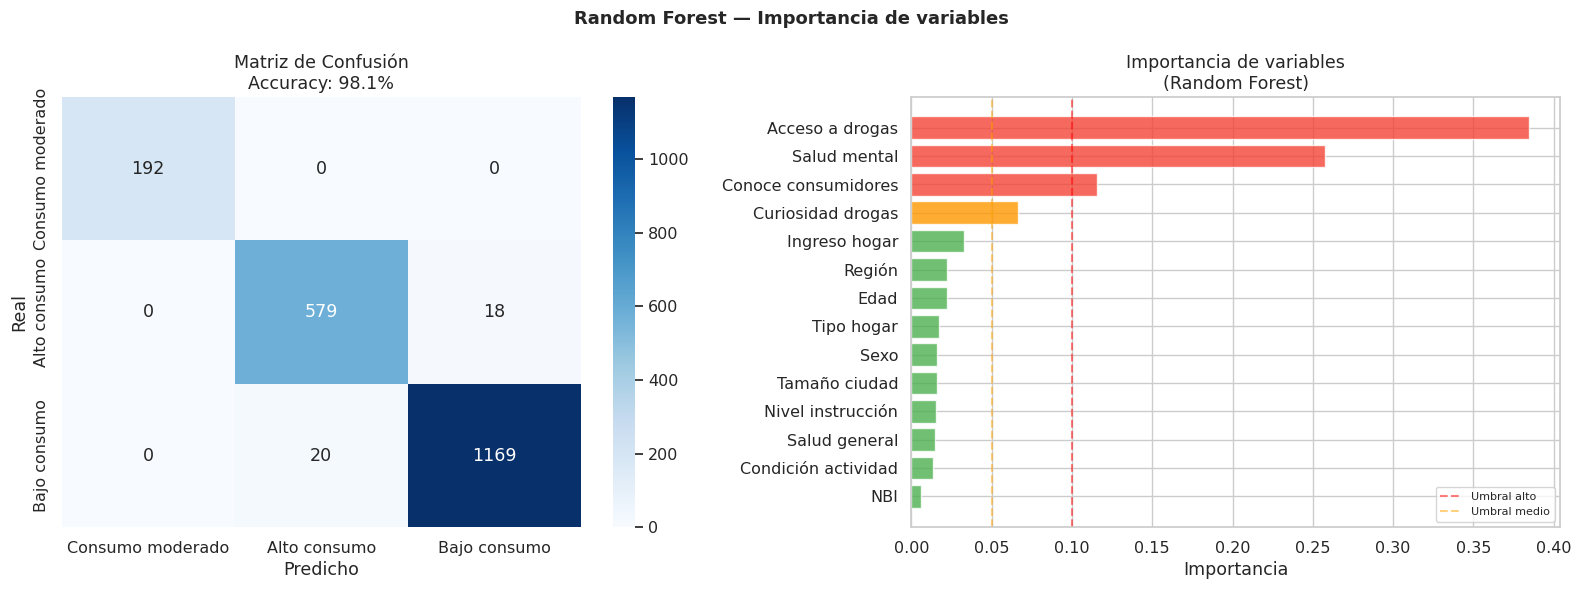

✅ Gráfico 16 guardado


In [ ]:
# ============================================
# RANDOM FOREST — VISUALIZACIÓN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest — Importancia de variables',
             fontsize=13, fontweight='bold')

# Matriz de confusión
nombres_clusters = ['Consumo moderado', 'Alto consumo', 'Bajo consumo']
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clusters,
            yticklabels=nombres_clusters,
            ax=axes[0])
axes[0].set_title(f'Matriz de Confusión\nAccuracy: {accuracy_score(y_test, y_pred):.1%}')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Importancia de variables
importancia_rf = pd.Series(
    rf.feature_importances_,
    index=vars_nombres
).sort_values(ascending=True)

colores = ['#F44336' if v > 0.1 else '#FF9800' if v > 0.05 else '#4CAF50'
           for v in importancia_rf.values]

axes[1].barh([nombres_display[v] for v in importancia_rf.index],
             importancia_rf.values,
             color=colores, alpha=0.8)
axes[1].set_title('Importancia de variables\n(Random Forest)')
axes[1].set_xlabel('Importancia')
axes[1].axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Umbral alto')
axes[1].axvline(x=0.05, color='orange', linestyle='--', alpha=0.5, label='Umbral medio')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('grafico16_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 16 guardado")

🔍Se observa:
> Matriz de confusión
- Consumo moderado: 192/192 correctos (100% ✅)
- Alto consumo: 579/597 correctos (97% ✅)
- Bajo consumo: 1169/1189 correctos (98% ✅)
- Solo 38 errores en 1.978 predicciones

> Random Forest (Importancia de variables):
| Variable | Importancia | Nivel
|---|---|---
| 1° Acceso a drogas | ~0.38 | 🔴 Alto
| 2° Salud mental | ~ 0.25 | 🔴 Alto
| 3° Conoce consumidores | ~0.11 | 🔴 Alto
| 4° Curiosidad drogas | ~0.06 | 🟡 Medio
| 5° Ingreso hogar | ~0.04 | 🟢 Bajo

🔖Hallazgo final

Los cuatro métodos usados coinciden en las siguientes variables:

✅ Acceso a drogas      → 1° en PCA, RF y top 3 en todos

✅ Conoce consumidores  → top 3 en todos los métodos

✅ Curiosidad drogas    → top 5 en todos los métodos

✅ Salud mental         → destacada en RF y centroides

# Análisis Comparativo Temporal: ENPreCoSP 2011 vs ENCoPraC 2022

Para contextualizar la evolución del consumo de sustancias psicoactivas
en jóvenes, quiero comparar las prevalencias del último año entre ambas
encuestas nacionales. Esta comparación permite identificar si el consumo
aumentó, disminuyó o se mantuvo estable en el período 2011-2022.

⚠️ Nota: la ENCoPraC 2022 no permite desagregación por provincia,
por lo que esta comparación se realiza a nivel nacional.

In [ ]:
# ============================================
# CARGA ENCoPraC 2022 - Exploración del dataset
# ============================================

df_2022 = pd.read_csv(
    '/content/drive/MyDrive/Aprendizaje Automático/Parcial/Archivos Parcial/base_usuario_encoprac2022.txt',
    sep='|',
    encoding='latin-1',
    index_col=False
)

# ---- TIPOS DE DATOS ----
print("\n=== TIPOS DE DATOS ===")
print(df_2022.dtypes.value_counts())

# ---- FILTRO JÓVENES 16-24 AÑOS ----
jovenes_2022 = df_2022[df_2022['GRUPO_EDAD_SEL'] == 1].copy()
print(f"\n=== SUBCONJUNTO JÓVENES 16-24 AÑOS ===")
print(f"Registros: {len(jovenes_2022):,}")


=== TIPOS DE DATOS ===
float64    406
int64      136
object      20
Name: count, dtype: int64

=== SUBCONJUNTO JÓVENES 16-24 AÑOS ===
Registros: 1,798


In [ ]:
# ---- VARIABLES DEL DATASET 2022 ----
vars_2022 = {
    'SEXO_SEL':            'Sexo',
    'EDAD_SEL':            'Edad en años cumplidos',
    'GRUPO_EDAD_SEL':      'Grupo etario (1 = 16-24 años)',
    'NIVEL_EDUCATIVO_SEL': 'Nivel de instrucción',
    'COBERTURA_SEL':       'Cobertura de salud',
    'CLIMA_EDUCATIVO':     'Clima educativo del hogar',
    'SA_03':               'Estado de salud percibido',
    'SA_05':               'Atención salud mental (último año)',
    'P1A_AL':              'Alcohol (último año)',
    'P1A_TA':              'Tabaco (último año)',
    'P1A_MA':              'Marihuana (último año)',
    'P1A_TR':              'Tranquilizantes sin receta (último año)',
}

tabla_vars = pd.DataFrame({
    'Variable': list(vars_2022.keys()),
    'Descripción': list(vars_2022.values()),
    'Valores únicos': [df_2022[v].nunique() for v in vars_2022],
    'Nulos': [df_2022[v].isnull().sum() for v in vars_2022],
})

print("=== VARIABLES SELECCIONADAS ===")
print(tabla_vars.to_string(index=False))

=== VARIABLES SELECCIONADAS ===
           Variable                             Descripción  Valores únicos  Nulos
           SEXO_SEL                                    Sexo               2      0
           EDAD_SEL                  Edad en años cumplidos              60      0
     GRUPO_EDAD_SEL           Grupo etario (1 = 16-24 años)               5      0
NIVEL_EDUCATIVO_SEL                    Nivel de instrucción               7      0
      COBERTURA_SEL                      Cobertura de salud               3      0
    CLIMA_EDUCATIVO               Clima educativo del hogar               4      0
              SA_03               Estado de salud percibido               6      0
              SA_05      Atención salud mental (último año)               3      0
             P1A_AL                    Alcohol (último año)               2      0
             P1A_TA                     Tabaco (último año)               2      0
             P1A_MA                  Marihuana (último 

In [ ]:
# ---- PERFIL DEL SUBCONJUNTO JÓVENES 16-24 AÑOS ----
print("\n" + "="*60)
print("PERFIL DEL SUBCONJUNTO DE TRABAJO (16-24 AÑOS)")
print("="*60)

total_22 = len(jovenes_2022)

# ---- SEXO ----
varones_2022 = (jovenes_2022['SEXO_SEL'] == 1).sum()
mujeres_2022 = (jovenes_2022['SEXO_SEL'] == 2).sum()
print("\nSexo")
print(f"  Varón: {varones_2022:,} ({varones_2022/total_22*100:.1f}%)")
print(f"  Mujer: {mujeres_2022:,} ({mujeres_2022/total_22*100:.1f}%)")

# ---- EDAD ----
print("\nEdad")
print(f"  Promedio: {jovenes_2022['EDAD_SEL'].mean():.1f} años")
print(f"  Mínima:   {jovenes_2022['EDAD_SEL'].min()}")
print(f"  Máxima:   {jovenes_2022['EDAD_SEL'].max()}")

# ---- CONSUMO ÚLTIMO AÑO ----
consumos_22 = {
    'Alcohol (último año)':              'P1A_AL',
    'Tabaco (último año)':               'P1A_TA',
    'Marihuana (último año)':            'P1A_MA',
    'Tranquilizantes sin receta (último año)': 'P1A_TR',
}

print("\nConsumo de sustancias (último año)")
print("-"*60)
for nombre, variable in consumos_22.items():
    consumidores = (jovenes_2022[variable] == 1).sum()
    porcentaje   = consumidores / total_22 * 100
    print(f"{nombre}: {consumidores:,} consumidores ({porcentaje:.1f}%)")


PERFIL DEL SUBCONJUNTO DE TRABAJO (16-24 AÑOS)

Sexo
  Varón: 860 (47.8%)
  Mujer: 938 (52.2%)

Edad
  Promedio: 20.1 años
  Mínima:   16
  Máxima:   24

Consumo de sustancias (último año)
------------------------------------------------------------
Alcohol (último año): 1,262 consumidores (70.2%)
Tabaco (último año): 412 consumidores (22.9%)
Marihuana (último año): 312 consumidores (17.4%)
Tranquilizantes sin receta (último año): 48 consumidores (2.7%)


In [ ]:
# ---- TABLA DE CONSUMO ESTILIZADA ----
tabla_consumo_22 = []
for nombre, variable in consumos_22.items():
    consumidores = (jovenes_2022[variable] == 1).sum()
    porcentaje   = consumidores / total_22 * 100
    tabla_consumo_22.append([variable, nombre.split(' (')[0], consumidores, round(porcentaje, 1)])

tabla_consumo_22 = pd.DataFrame(
    tabla_consumo_22,
    columns=['Variable', 'Sustancia', 'Consumidores (último año)', 'Porcentaje (%)']
)

tabla_consumo_22.style.format({
    'Consumidores (último año)': '{:,.0f}',
    'Porcentaje (%)': '{:.1f}%'
})

,Variable,Sustancia,Consumidores (último año),Porcentaje (%)
0,P1A_AL,Alcohol,"1,262",70.2%
1,P1A_TA,Tabaco,412,22.9%
2,P1A_MA,Marihuana,312,17.4%
3,P1A_TR,Tranquilizantes sin receta,48,2.7%


## Equivalencias de variables 2011 -> 2022

In [ ]:
# ---- TABLA DE EQUIVALENCIAS ----
equivalencias = pd.DataFrame([
    ('BHCH04',   'Sexo',                       'SEXO_SEL',            '✅ Comparable'),
    ('BHCH05',   'Edad',                        'EDAD_SEL',            '✅ Comparable'),
    ('NIVINSTR', 'Nivel de instrucción',        'NIVEL_EDUCATIVO_SEL', '✅ Escala distinta'),
    ('BISG01',   'Autopercepción de salud',     'SA_03',               '✅ Escala distinta'),
    ('BISG04',   'Visita salud mental',         'SA_05',               '✅ Aproximado'),
    ('P1A_BA',   'Alcohol (último año)',        'P1A_AL',              '✅ Comparable'),
    ('P1A_TA',   'Tabaco (último año)',         'P1A_TA',              '✅ Comparable'),
    ('P1A_MA',   'Marihuana (último año)',      'P1A_MA',              '✅ Comparable'),
    ('P1A_TR',   'Tranquilizantes (últ. año)', 'P1A_TR',              '✅ Comparable'),
    ('CONDACT',  'Condición de actividad',      '—',                   '❌ No disponible'),
    ('RANGOING', 'Ingreso del hogar',           '—',                   '❌ No disponible'),
    ('NBI_TOTAL','NBI',                         '—',                   '❌ No disponible'),
    ('BIAC01',   'Conoce consumidores',         '—',                   '❌ No disponible'),
    ('BIAC03',   'Curiosidad por drogas',       '—',                   '❌ No disponible'),
    ('BIAC04',   'Acceso a drogas',             '—',                   '❌ No disponible'),
    ('PRVNC',    'Provincia',                   '—',                   '❌ No disponible'),
], columns=['Variable 2011', 'Descripción', 'Variable 2022', 'Estado'])

print("=== EQUIVALENCIAS DE VARIABLES 2011 → 2022 ===\n")
print(equivalencias.to_string(index=False))

comparables    = equivalencias['Estado'].str.contains('✅').sum()
no_disponibles = equivalencias['Estado'].str.contains('❌').sum()
print(f"\nVariables comparables:    {comparables}")
print(f"Variables no disponibles: {no_disponibles}")

=== EQUIVALENCIAS DE VARIABLES 2011 → 2022 ===

Variable 2011                Descripción       Variable 2022            Estado
       BHCH04                       Sexo            SEXO_SEL      ✅ Comparable
       BHCH05                       Edad            EDAD_SEL      ✅ Comparable
     NIVINSTR       Nivel de instrucción NIVEL_EDUCATIVO_SEL ✅ Escala distinta
       BISG01    Autopercepción de salud               SA_03 ✅ Escala distinta
       BISG04        Visita salud mental               SA_05      ✅ Aproximado
       P1A_BA       Alcohol (último año)              P1A_AL      ✅ Comparable
       P1A_TA        Tabaco (último año)              P1A_TA      ✅ Comparable
       P1A_MA     Marihuana (último año)              P1A_MA      ✅ Comparable
       P1A_TR Tranquilizantes (últ. año)              P1A_TR      ✅ Comparable
      CONDACT     Condición de actividad                   —   ❌ No disponible
     RANGOING          Ingreso del hogar                   —   ❌ No disponible
    

In [ ]:
equivalencias.style.applymap(
    lambda v: 'color: green; font-weight: bold' if '✅' in str(v)
              else ('color: red' if '❌' in str(v) else ''),
    subset=['Estado']
)

,Variable 2011,Descripción,Variable 2022,Estado
0,BHCH04,Sexo,SEXO_SEL,✅ Comparable
1,BHCH05,Edad,EDAD_SEL,✅ Comparable
2,NIVINSTR,Nivel de instrucción,NIVEL_EDUCATIVO_SEL,✅ Escala distinta
3,BISG01,Autopercepción de salud,SA_03,✅ Escala distinta
4,BISG04,Visita salud mental,SA_05,✅ Aproximado
5,P1A_BA,Alcohol (último año),P1A_AL,✅ Comparable
6,P1A_TA,Tabaco (último año),P1A_TA,✅ Comparable
7,P1A_MA,Marihuana (último año),P1A_MA,✅ Comparable
8,P1A_TR,Tranquilizantes (últ. año),P1A_TR,✅ Comparable
9,CONDACT,Condición de actividad,—,❌ No disponible


In [ ]:
# ============================================
# COMPARACIÓN TEMPORAL 2011 vs 2022
# ============================================

print("=== PREVALENCIAS COMPARATIVAS 2011 vs 2022 ===")
print(f"{'Sustancia':<25} {'2011':>8} {'2022':>8} {'Cambio':>10}")
print("-" * 55)

comparacion = {
    'Alcohol':         ('P1A_BA', 'P1A_AL'),
    'Tabaco':          ('P1A_TA', 'P1A_TA'),
    'Marihuana':       ('P1A_MA', 'P1A_MA'),
    'Tranquilizantes': ('P1A_TR', 'P1A_TR'),
}

resultados = {}
for sustancia, (v_2011, v_2022) in comparacion.items():
    pct_2011 = (jovenes[v_2011] == 1).sum() / len(jovenes) * 100
    pct_2022 = (jovenes_2022[v_2022] == 1).sum() / len(jovenes_2022) * 100
    cambio = pct_2022 - pct_2011
    signo = '↑' if cambio > 0 else '↓'
    resultados[sustancia] = (pct_2011, pct_2022, cambio)
    print(f"{sustancia:<25} {pct_2011:>7.1f}% {pct_2022:>7.1f}% {signo}{abs(cambio):>7.1f}%")

print(f"\nBase 2011: {len(jovenes):,} jóvenes")
print(f"Base 2022: {len(jovenes_2022):,} jóvenes")

=== PREVALENCIAS COMPARATIVAS 2011 vs 2022 ===
Sustancia                     2011     2022     Cambio
-------------------------------------------------------
Alcohol                      67.4%    70.2% ↑    2.8%
Tabaco                       32.4%    22.9% ↓    9.5%
Marihuana                     4.3%    17.4% ↑   13.1%
Tranquilizantes               1.1%     2.7% ↑    1.5%

Base 2011: 6,592 jóvenes
Base 2022: 1,798 jóvenes


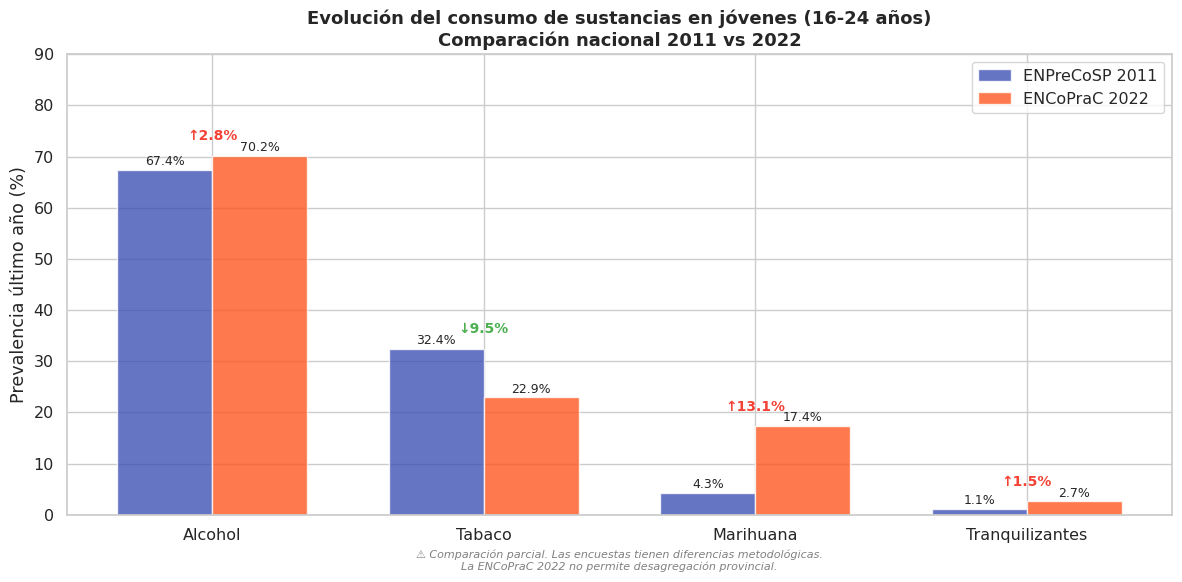

✅ Gráfico 17 guardado


In [ ]:
# ============================================
# GRÁFICO — COMPARACIÓN TEMPORAL 2011 vs 2022
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

sustancias = list(resultados.keys())
pcts_2011 = [resultados[s][0] for s in sustancias]
pcts_2022 = [resultados[s][1] for s in sustancias]
cambios = [resultados[s][2] for s in sustancias]

x = np.arange(len(sustancias))
width = 0.35

bars1 = ax.bar(x - width/2, pcts_2011, width,
               label='ENPreCoSP 2011', color='#3F51B5', alpha=0.8)
bars2 = ax.bar(x + width/2, pcts_2022, width,
               label='ENCoPraC 2022', color='#FF5722', alpha=0.8)

# Valores encima de las barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

# Flechas de cambio
for i, (s, cambio) in enumerate(zip(sustancias, cambios)):
    color = '#F44336' if cambio > 0 else '#4CAF50'
    signo = '↑' if cambio > 0 else '↓'
    ax.text(i, max(pcts_2011[i], pcts_2022[i]) + 3,
            f'{signo}{abs(cambio):.1f}%',
            ha='center', fontsize=10, fontweight='bold', color=color)

ax.set_title('Evolución del consumo de sustancias en jóvenes (16-24 años)\nComparación nacional 2011 vs 2022',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Prevalencia último año (%)')
ax.set_xticks(x)
ax.set_xticklabels(sustancias)
ax.legend()
ax.set_ylim(0, 90)

# Nota aclaratoria
ax.text(0.5, -0.12,
        '⚠️ Comparación parcial. Las encuestas tienen diferencias metodológicas.\n'
        'La ENCoPraC 2022 no permite desagregación provincial.',
        transform=ax.transAxes, ha='center', fontsize=8,
        style='italic', color='gray')

plt.tight_layout()
plt.savefig('grafico17_comparacion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 17 guardado")

🆚 *Este análisis comparativo temporal revela que entre 2011 y 2022 el consumo de marihuana en jóvenes de 16 a 24 años aumentó de 4.3% a 17.4%, prácticamente cuadruplicándose. Este incremento coincide con los cambios legislativos y culturales que se han dado en Argentina durante este período. Es importante nombrar la sanción de la Ley 27.350 de uso medicinal del cannabis en 2017 y la posterior reglamentación del autocultivo en 2020.*

- 2017 -> Se aprobó la Ley 27.350 de uso medicnal del cannabis
- 2020 -> Se reglamentó el autocultivo y uso personal
- 2021 -> Se intensifica el debate público sobre la despenalización


---
# 📊 Conclusiones Finales
---


## 1. 👥Sobre los perfiles de consumo descubiertos
K-Means (K=3) y DBSCAN identificaron tres perfiles naturales de consumo
en jóvenes argentinos de 16 a 24 años:
- **🟢Perfil de bajo consumo** (60,1%): mayoría de los jóvenes, con consumo
  moderado de alcohol y muy bajo de otras sustancias.
- **🔴Perfil de alto consumo** (30,2%): consumo elevado de alcohol (87,1%),
  tabaco (49,4%) y marihuana (11,8%).
- **🟡Perfil de consumo moderado** (9,7%): grupo intermedio con consumo
  de alcohol y tabaco sin sustancias ilícitas.

> ✅La validación mediante Random Forest alcanzó un accuracy del 98,1%,
confirmando que los clusters son significativos y no aleatorios.

## 2. 🔍Sobre los factores más influyentes
Los tres métodos de interpretación de variables coincidieron en que
los factores más asociados al consumo son:
- 🥇 **Acceso a drogas** → el factor más determinante en todos los métodos
- 🥈 **Conocer consumidores cercanos** → la presión del entorno social
- 🥉 **Curiosidad por probar drogas** → la predisposición personal
- **4°** **Ingreso del hogar** → el nivel económico facilita el acceso

> ⚠️Las variables socioeconómicas tradicionales como NBI y tipo de hogar
resultaron poco influyentes, sugiriendo que el consumo en jóvenes
está más asociado al entorno social que a la pobreza.

## 3. 🏔️Sobre el perfil específico de Tierra del Fuego
Los jóvenes fueguinos presentan un perfil de consumo diferenciado
respecto al resto del país:
- El 51,3% pertenece al cluster de alto consumo vs 30,2% nacional
- Mayor prevalencia en alcohol (73,6% vs 67,4%), tabaco (40,0% vs 32,4%)
  y marihuana (6,0% vs 4,3%)
- Mayor exposición al entorno consumidor (46% vs 39,6%) y mayor
  acceso percibido a drogas (52,1% vs 34,8%)

> 💡A pesar de mejores condiciones económicas, presentan mayor consumo,
  lo que sugiere que el aislamiento geográfico y la mayor disponibilidad
  de ingresos son factores de riesgo específicos del territorio.

## 4. 📅Sobre la evolución temporal 2011–2022
La comparación con la ENCoPraC 2022 reveló tendencias significativas:
- 🌿**Marihuana:** aumentó de 4,3% a 17,4% (+13,1%), coincidiendo con
  los cambios legislativos de la Ley 27.350 (2017) y la reglamentación
  del autocultivo (2020).
- 🚬**Tabaco:** disminuyó de 32,4% a 22,9% (-9,5%), reflejando el impacto
  de políticas de control del tabaquismo.
- 🍺**Alcohol:** leve aumento de 67,4% a 70,2% (+2,8%).
- 💊**Tranquilizantes:** leve aumento de 1,1% a 2,7% (+1,6%).

> ⚠️ Esta comparación es parcial debido a diferencias metodológicas entre ambas encuestas y a que la ENCoPraC 2022 no permite desagregación provincial.

> 📌 El aumento de marihuana coincide con la sanción de la **Ley 27.350** (2017) y la reglamentación del autocultivo (2020).

## 5. ⚠️Limitaciones del estudio

### **Limitaciones del modelo**
- EL coeficiente de Silhouette obtenido (0,140) es bajo, auqnue esperable cuando se trabaja con comportamientos humanos. Como señala Rousseeuw(1987), las conductas sociales no se dividen en grupos nítidos: las personas no encajan perfectamente en categorías, y esa superposición no es un error del método sino un reflejo de los fenómenos sociales.
- DBSCAN identificó 896 jóvenes (13,6%) como outliers con perfiles atípicos. Su distribución dispersa en el espacio PCA sugiere que son perfiles diversos y no un grupo homogéneo, lo que limita su interpretación.

### **Limitaciones del dataset**
- El subconjunto de Tierra del Fuego es reducido (N=265), lo que implica mayor margen de error en las estimaciones territoriales y limita la generalización de los hallazgos provinciales.
- El dataset ENPreCoSP 2011 tiene 13 años de antigüedad, aunque la comparación con la ENCoPraC 2022 permite contextualizar parcialmente esta limitación.

### **Limitaciones de la comparación temporal**
- La ENCoPraC 2022 no incluye variable de provincia ni región, lo que impide reproducir el análisis territorial.
- De las 15 variables predictoras utilizadas en el clustering, solo 4 tienen equivalente directo en 2022. Las variables de entorno social (BIAC01, BIAC03, BIAC04), ingresos y NBI no están disponibles, por lo que la comparación temporal queda acotada exclusivamente a prevalencias de consumo.

## 6. 🚀Recomendaciones y futuras líneas de investigación

### **Futuras líneas de investigación**

- 🧠**Incorporación de variables de salud mental:** Este estudio identificó que
la visita a profesionales de salud mental (BISG04) fue prácticamente irrelevante para diferenciar clusters (diferencia de medias: 0,005), auqnue esto dice mas sobre los límites del indicador que sobre la relación entre salud mental y consumo. Futuras investigaciones deberían incorporar variables más completas — ansiedad, depresión, estrés percibido — para explorar su relación con el consumo.

- 🗺️**Extensión a provincias con perfil similar:** ¿Es Tierra del Fuego un caso aislado, o parte de algo mas grande? Neuquén, Santa Cruz y Chubut comparten con Tierra del Fuego las mismas características que este estudio identificó como factores de riesgo: aislamiento geográfico, altos ingresos y migración interna. Aplicar el mismo enfoque en estas provincias permitiría responder a esa pregunta, y si el patrón se repite, estaríamos ante un fenómeno patagónico.


- 📽️**Análisis longitudinal:** El límite más estructural de este trabajo es que
es una foto, no una película. Muestra cómo estaban distribuidos los jóvenes
en 2011, pero no puede explicar cómo llegaron ahí ni hacia dónde van. Un
diseño longitudinal — que siga a los mismos individuos en el tiempo —
permitiría identificar trayectorias reales: qué jóvenes del cluster de bajo
consumo migran al de alto consumo, en qué momento, y bajo qué condiciones.
Eso es lo que este estudio no puede responder, y es exactamente lo que
más importa para prevenir.

---
---

In [ ]:
# ============================================
# EXPORTAR DATASETS A CSV
# ============================================

# Dataset 2011 — solo el subconjunto de jóvenes
jovenes.to_csv('/content/drive/MyDrive/Aprendizaje Automático/Parcial/Archivos Parcial/ENPreCoSP_2011_jovenes_16_24.csv',
               index=False, encoding='utf-8')
print("✅ ENPreCoSP 2011 exportado")

# Dataset 2022 — solo el subconjunto de jóvenes
jovenes_2022.to_csv('/content/drive/MyDrive/Aprendizaje Automático/Parcial/Archivos Parcial/ENCoPraC_2022_jovenes_16_24.csv',
                    index=False, encoding='utf-8')
print("✅ ENCoPraC 2022 exportado")

print(f"\nENPreCoSP 2011: {len(jovenes):,} registros, {jovenes.shape[1]} variables")
print(f"ENCoPraC 2022:  {len(jovenes_2022):,} registros, {jovenes_2022.shape[1]} variables")

✅ ENPreCoSP 2011 exportado
✅ ENCoPraC 2022 exportado

ENPreCoSP 2011: 6,592 registros, 293 variables
ENCoPraC 2022:  1,798 registros, 562 variables
